# Analysis of NHS appointments

### This workbook demonstrates how data has been imported from various files, wrangled and visualised to gain insights to key questions posed in the business problem

### It is divided into 5 sections:

### 1. Importing the datasets
### 2. Exploring the datsets using basic stats
### 3. Exploring the twitter dataset
### 4. Exploring the NHS appointment data sets with visuals
### 5. Make recommendations to the NHS. 
###

## 1. Importing the datasets

In [1]:
# Import the necessary libraries.
import pandas as pd
import numpy as np
import datetime 
from datetime import datetime, date 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

#### Importing the Actual Duration dataset

In [2]:
ad = pd.read_csv("actual_duration.csv")

# Count rows and coiumns in the dataframe and its meta data.
print("The number of rows and columns in the data set is\n", ad.shape )
print("\n")
print(ad.info())

The number of rows and columns in the data set is
 (137793, 8)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB
None


In [3]:
# Determine whether there are missing values.
ad_na = ad[ad.isna().any(axis=1)]
ad_na.shape

(0, 8)

#### Observation: Above there are no rows with missing or null values in the actual duration dataset 

In [4]:
# How many 'Unknown / Data Quality' values are there in the 'actual duration column.
ad['actual_duration'].value_counts()

actual_duration
Unknown / Data Quality    20161
1-5 Minutes               19909
6-10 Minutes              19902
11-15 Minutes             19738
16-20 Minutes             19534
21-30 Minutes             19452
31-60 Minutes             19097
Name: count, dtype: int64

#### Observation: Above there are 20,161 unknown or data quality record in the 'actual duration' column, out of 137,793 records (14%). These are appointments with a null duration or a duration of less than one minute or greater than 60 minutes

In [5]:
# View the DataFrame
ad.head()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


### Importing the National Categories dataset

In [6]:
nc = pd.read_excel("national_categories.xlsx")

# Count rows and coiumns in the dataframe and its meta data.
print("The number of rows and columns in the data set is\n", nc.shape )
print("\n")
print(nc.info())

The number of rows and columns in the data set is
 (817394, 8)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 49.9+ MB
None


In [7]:
# Determine whether there are missing values.
nc_na = nc[nc.isna().any(axis=1)]
nc_na.shape

(0, 8)

#### Observation: Above there are no rows with missing or null values in the actual duration dataset 

In [8]:
# How many 'Unknown / Data Quality' values are there in the context type column.
nc['context_type'].value_counts()

context_type
Care Related Encounter    700481
Inconsistent Mapping       89494
Unmapped                   27419
Name: count, dtype: int64

#### Observation: Above There are 89,494 inconsistent mapping records out of a total of 817,394 (10%). These have been mapped but not to a Care Related Encounter.
#### There are also 27,419 unmapped records out of a total of 817,394 (3%). This could be due to an error receiving the data, or an appointment type has not been mapped

In [9]:
# View the DataFrame
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


### Importing the Appointments Regional dataset

In [10]:
ar = pd.read_csv("appointments_regional.csv")

# Count rows and coiumns in the dataframe and its meta data.
print("The number of rows and columns in the data set is\n", ar.shape )
print("\n")
print(ar.info())

The number of rows and columns in the data set is
 (596821, 7)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB
None


In [11]:
# Determine whether there are missing values.
ar_na = ar[ar.isna().any(axis=1)]
ar_na.shape

(0, 7)

#### Observation: Above there are no rows with missing or null values in the actual duration dataset 

In [12]:
# How many 'Unknown / Data Quality' values are there in the context type column.
ar['appointment_status'].value_counts()

appointment_status
Attended    232137
Unknown     201324
DNA         163360
Name: count, dtype: int64

#### Observation: Above there are 201,324 records with a status of unknown out of a total of 596,821 (33%). It is difficult to determine if these appointments were attended as their final status remained as booked.

In [13]:
# View the DataFrame
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


## 2. Exploring the datasets

#### Question: Determine the number of unique ICBs in the data set.

In [14]:
num_locations = ad['icb_ons_code'].nunique()

print("The number of unique ICBs in all 3 datasets is:", num_locations)

The number of unique ICBs in all 3 datasets is: 42


#### Question: Top five ICBs based on record count

In [15]:
Top5_Locations = (ad.groupby('icb_ons_code')['count_of_appointments'].sum().sort_values(ascending=False).head(5))

print(f"The top 5 ICBs with the highest number of appointments are\n{Top5_Locations} ")

The top 5 ICBs with the highest number of appointments are
icb_ons_code
E54000050    9584943
E54000054    8291440
E54000057    7650341
E54000008    7344348
E54000027    6976986
Name: count_of_appointments, dtype: int64 


#### Question: Determine the number of service settings

In [16]:
num_service_settings = nc.groupby(['service_setting'])[['count_of_appointments']].sum().sort_values(by='count_of_appointments', ascending=False)

print(f"The number of service settings are: \n{num_service_settings}")

The number of service settings are: 
                           count_of_appointments
service_setting                                 
General Practice                       270811691
Unmapped                                11080810
Primary Care Network                     6557386
Other                                    5420076
Extended Access Provision                2176807


#### Observation: Above GP practices account for 270,811,691 appointments or 91% of the total

#### Question: Determine the number of context types

In [17]:
num_context_type = nc.groupby(['context_type'])[['count_of_appointments']].sum().sort_values(by='count_of_appointments', ascending=False)

print(f"The number of context types are: \n{num_context_type} ")

The number of context types are: 
                        count_of_appointments
context_type                                 
Care Related Encounter              257075158
Inconsistent Mapping                 27890802
Unmapped                             11080810 


#### Observation: Above Care related encounters account for 257,075,158 of the appointments or 87% of the total

#### Question: Determine the number of national categories.

In [18]:
num_national_categories = nc.groupby(['national_category'])[['count_of_appointments']].sum().sort_values(by='count_of_appointments', ascending=False)

print(f"The number of national categories are: \n{num_national_categories}")

The number of national categories are: 
                                                    count_of_appointments
national_category                                                        
General Consultation Routine                                     97271522
General Consultation Acute                                       53691150
Clinical Triage                                                  41546964
Planned Clinics                                                  28019748
Inconsistent Mapping                                             27890802
Planned Clinical Procedure                                       25702694
Unmapped                                                         11080810
Unplanned Clinical Activity                                       3055794
Home Visit                                                        2144452
Structured Medication Review                                      1858379
Service provided by organisation external to th...                 85213

#### Observation: Above General Consultation Routine account for 33% and General Consultation Acute 18% of the total appointments

#### Question: Determine the number of appointment statuses

In [19]:
# First change the data type of appointment month to datetime
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'])

# Then filter the data to look at appointments from Aug-21 onwards as most meaningful national categories were captured from this date onwards
Aug21_onwards_df = ar.loc[(ar['appointment_month']>='2021-08-01') & (ar['appointment_month']<='2022-06-01')]

# Finally count the statuses
num_appt_status = Aug21_onwards_df.groupby(['appointment_status'])[['count_of_appointments']].sum().sort_values(by='count_of_appointments', ascending=False)

print(f"The number of appointment statuses from Aug-21 onwards are: \n{num_appt_status}")

The number of appointment statuses from Aug-21 onwards are: 
                    count_of_appointments
appointment_status                       
Attended                        270657694
DNA                              13318384
Unknown                          12070692


#### Observation: Above 270 million appointments were attended (91%) and 13 million were not attended (4%) between Aug-21 and June-22

#### Question: Which month had the highest number of appointments

In [20]:
# First change the data type of appointment month to datetime
nc['appointment_month'] = pd.to_datetime(nc['appointment_month'])

# Then group the appointments by month to see the busiest month
nc.groupby('appointment_month')[['count_of_appointments']].sum().sort_values(by='count_of_appointments', ascending=False).style.format({'count_of_appointments': '{:,}'})

,count_of_appointments
appointment_month,
2021-11-01 00:00:00,"30,405,070"
2021-10-01 00:00:00,"30,303,834"
2022-03-01 00:00:00,"29,595,038"
2021-09-01 00:00:00,"28,522,501"
2022-05-01 00:00:00,"27,495,508"
2022-06-01 00:00:00,"25,828,078"
2022-01-01 00:00:00,"25,635,474"
2022-02-01 00:00:00,"25,355,260"
2021-12-01 00:00:00,"25,140,776"


#### Observation: Above Nov-21 appears to be the busiest month in terms of appointments with 30,405,070 bookings

#### Question : Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [21]:
# For each of these service settings, determine the number of records available for the period and the location. 
NWLondon = nc.loc[(nc['sub_icb_location_name']=='NHS North West London ICB - W2U3Z') & \
        (nc['appointment_month']>='2022-01-01') & (nc['appointment_month']<='2022-06-01')]

# View the output.
NWLondon.groupby(['service_setting'])[['count_of_appointments']].sum().sort_values(by='count_of_appointments', ascending=False).style.format({'count_of_appointments': '{:,}'})

,count_of_appointments
service_setting,
General Practice,"5,719,516"
Unmapped,"462,758"
Other,"181,576"
Primary Care Network,"130,526"
Extended Access Provision,"115,052"


#### Observation above: GPs account for the most common service setting in NW London

## 3. Exploring the twitter dataset

In [22]:
# Set figure size for visuals.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [23]:
# Load the data set.
tweets = pd.read_csv('tweets.csv')

# View the DataFrame.
tweets.head(2)

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en


In [24]:
# Explore the metadata.
print(tweets.shape)
print(tweets.dtypes)

(1174, 10)
tweet_id                    int64
tweet_full_text            object
tweet_entities             object
tweet_entities_hashtags    object
tweet_metadata             object
tweet_retweet_count         int64
tweet_favorite_count        int64
tweet_favorited              bool
tweet_retweeted              bool
tweet_lang                 object
dtype: object


#### Question: Would it be useful to only look at retweeted and favourite tweet messages?

In [25]:
#Counting retweets by converting them to lower case and showing top 10
retweets = tweets.groupby(tweets['tweet_entities_hashtags'].str.lower())['tweet_retweet_count'].sum().sort_values(ascending=False)
retweets.head(10) # Show top 10 retweets

tweet_entities_hashtags
#healthcare                                                                                            1193
#applications, #ai, #healthcare, #digitalhealth, #healthtech, #health, #datascience, #bigdata           600
#saskatchewan                                                                                           257
#ai                                                                                                     229
#data, #healthcare                                                                                      228
#robotic, #mi, #robotics, #tech, #technology, #healthcare                                               176
#tipsfornewdocs, #meded, #medtwitter, #medicine, #medical                                               169
#wearable, #wearable                                                                                    156
#tipsfornewdocs, #meded, #medtwitter, #medicine, #medical, #medicare, #health, #healthcare, #foamed     120
#hea

#### The results above show the top 10 most retweeted hashtags. It is not possible to decipher if these relate to NHS appointment delays simply by looking at the hashtag names

#### Question: Give a breakdown of the most common hashtag i.e. #healthcare. Ignore upper or lower case. Show top 10 tweets

In [26]:
Healthcare_rows = tweets[tweets['tweet_entities_hashtags'].str.contains(r"#healthcare\b", case=False, na=False)]

#Create another dataset with only 2 columns to look at the tweet full text and the retweet counts
Popular_healthcare_retweets = Healthcare_rows[['tweet_full_text', 'tweet_retweet_count']]

#Sort this dataset to show only the top 10 retweets 
Popular_healthcare_retweets.sort_values(by='tweet_retweet_count', ascending=False).head(10).reset_index(drop=True)

,tweet_full_text,tweet_retweet_count
0,RT @Khulood_Almani: 🔟#Applications of #AI in #healthcare \n\nv/@ValueCoders\n \n#digitalhealth #Healthtech #Health #DataScience #Bigdata #Analy…,150
1,RT @Khulood_Almani: 🔟#Applications of #AI in #healthcare \n\nv/@ValueCoders\n \n#digitalhealth #Healthtech #Health #DataScience #Bigdata #Analy…,150
2,RT @Khulood_Almani: 🔟#Applications of #AI in #healthcare \n\nv/@ValueCoders\n \n#digitalhealth #Healthtech #Health #DataScience #Bigdata #Analy…,150
3,RT @Khulood_Almani: 🔟#Applications of #AI in #healthcare \n\nv/@ValueCoders\n \n#digitalhealth #Healthtech #Health #DataScience #Bigdata #Analy…,150
4,RT @Khulood_Almani: #Healthcare #DigitalTransformation Starts with This 6⃣Step Process\n\nv/@uptophealth\n#digitalhealth #AI #Python #DataScie…,107
5,"RT @SoniaFurstenau: Germany has one of the top ranked #healthcare systems in the world, while Canada’s is teetering. We both dedicate simil…",85
6,"RT @SoniaFurstenau: Germany has one of the top ranked #healthcare systems in the world, while Canada’s is teetering. We both dedicate simil…",85
7,"RT @SoniaFurstenau: Germany has one of the top ranked #healthcare systems in the world, while Canada’s is teetering. We both dedicate simil…",85
8,"RT @AWSCloudIndia: How is #data revolutionizing #healthcare? 💊 🚑 🏥 \n\nHear the prognosis from @DubeyPradeepK, Director of @intel's Parallel…",76
9,"RT @AWSCloudIndia: How is #data revolutionizing #healthcare? 💊 🚑 🏥 \n\nHear the prognosis from @DubeyPradeepK, Director of @intel's Parallel…",76


#### Observation: Looking at the results above AI in healthcare appears to be the most retweeted. Perhaps this is a future path for the NHS as well? But other than that there is no meaningful way of working out if these tweets relate to NHS appointments.

#### Question : Count the favourite tweets

In [27]:
fav_retweets = tweets.groupby(tweets['tweet_entities_hashtags'].str.lower())['tweet_favorite_count'].sum().sort_values(ascending=False)
fav_retweets.head(5) # Show top 5 retweets

tweet_entities_hashtags
#healthcare                                                                                                                                                                     76
#tipsfornewdocs, #meded, #medtwitter, #medicine, #medical, #medicare, #health, #healthcare, #foamed, #clinicalpearl, #clinicaltips, #medstudents, #medstudenttwitter, #lipid    59
#comedy, #adulting, #healthcare                                                                                                                                                 20
#healthcare, #cdnpoli                                                                                                                                                           18
#conv2x, #blockchain, #dlt, #healthcare, #innovation                                                                                                                            13
Name: tweet_favorite_count, dtype: int64

#### Question: Show the text of the most favourite tweet. Show the top ten tweets

In [28]:
#Create a dataset with only 2 columns to look at the tweet full text and the count of favourite tweets
Favourite_healthcare_tweets = Healthcare_rows[['tweet_full_text', 'tweet_favorite_count']]

#Sort this dataset to show only the top 10 retweets 
Favourite_healthcare_tweets.sort_values(by='tweet_favorite_count', ascending=False).head(10).reset_index(drop=True)

,tweet_full_text,tweet_favorite_count
0,Lipid-Lowering Drugs\n\n#TipsForNewDocs #MedEd #MedTwitter #medicine #medical #medicare #health #healthcare #FOAMed #ClinicalPearl #clinicaltips #MedStudents #medstudenttwitter #lipid \n\nCredit: ...,42
1,You ready for $JCO @_JennyCo ❤️\n\n#Healthcare data powered by @Conste11ation $DAG 🔥,28
2,How health insurance works 😂 \n\n#comedy #adulting #healthcare https://t.co/ciksdeoAkb,20
3,"Our nat’l choices re: #healthcare systems aren’t the continuum of public or private, but how much we want of:\n\n- fragmented or seamless\n- does simplicity or complexity well\n- prioritizes savin...",18
4,"Heart Failure, Myocardial Infarction &amp; immediate Treatment\n\n#TipsForNewDocs #MedEd #MedTwitter #medicine #medical #medicare #health #healthcare #FOAMed #ClinicalPearl #clinicaltips #MedStude...",17
5,"More data that our 13+ 🇨🇦 #healthcare systems fall short of providing adequate access to care, even for those w/ a family physician.\n\nInstead of siloed solutions and further system fragmentation...",14
6,Looking forward to speaking at #ConV2X on Sep 15! Ping me for a speaker discount if interested! Register at https://t.co/v20ebbXmdO \n\n.@BHTYjournal @hedera @acoerco\n#blockchain #DLT #healthcare...,13
7,@CapricornFMNews We have waiting to hear this kind of news now Sa is getting things correct there is absolutely nothing mahala #HealthCare services in SA must be paid by foreign nationals and loca...,12
8,September is #WomenInMedicine Month! Thrilled to join @JulieSilverMD #SheLeadsHealthcare @ELAMProgram &amp; @AMWADoctors to #InvestInHer!\n\nI #InvestInHer to diversify the #healthcare #leadersh...,11
9,Thanks &amp; Happy #WomenInMedicine Month to AMWA Board Member @SusanHingle! We appreciate your contributions to #Healthcare &amp; your leadership in AMWA! Learn about AMWA's community &amp; initi...,10


#### Observation: The above shows the top 10 most favourite healthcare related tweets. Again same with the retweets data, it is difficult to see if these relate to NHS appointments, so i would ignore the favourites tweets. 

In [29]:
# Create a new DataFrame containing only the text.
text_tweets = tweets['tweet_full_text']
# View the DataFrame.
text_tweets.head()

0    As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...
1                                                                RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed.  We're #hiring for…
2                                                             RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…
3                                                               RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…
4    ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take 

#### Question: Count all hashtags that appear in each tweet and then plot it on a bar plot

In [30]:
""" Extract hashtags from each tweet. Look at the tweet_full_text column. The findall() function looks for raw text using 'r' for a hashtag '#' 
The '\w+' looks for any letters or symbols and looks till the end using the '+' sign """ 

tweets["hashtags"] = tweets["tweet_full_text"].str.findall(r"#\w+")
tweets["hashtags"].head()

0                                                                           [#Healthcare]
1                                                               [#PremiseHealth, #hiring]
2                                                                           [#Healthcare]
3                                                                                  [#NEW]
4    [#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare]
Name: hashtags, dtype: object

In [31]:
""" If multiple tweets appear in the same row then flatten into a single series and convert everything to lowercase. The explode() function 
turns each value in the list into its own row """
hashtags = tweets["hashtags"].explode().str.lower()
hashtags

0              #healthcare
1           #premisehealth
1                  #hiring
2              #healthcare
3                     #new
               ...        
1173    #mediqueststaffing
1173             #hospital
1173                #shift
1173         #newportbeach
1173                  #job
Name: hashtags, Length: 4514, dtype: object

In [32]:
# Count most common hashtags and display the top 30 values
top_hashtags = hashtags.value_counts()
print(top_hashtags.head(30))

hashtags
#healthcare                 844
#health                      88
#ai                          47
#medicine                    42
#job                         38
#medical                     35
#digitalhealth               31
#strategy                    31
#pharmaceutical              28
#medtwitter                  27
#marketing                   25
#biotech                     25
#pharma                      25
#competitiveintelligence     25
#meded                       24
#telehealth                  22
#covid                       21
#tipsfornewdocs              21
#hiring                      21
#healthtech                  18
#vaccine                     18
#technology                  18
#machinelearning             18
#medicare                    17
#news                        17
#womeninmedicine             16
#coronavirus                 16
#competitivemarketing        16
#tech                        15
#covid19                     15
Name: count, dtype: int64


In [33]:
# Convert the series to a DataFrame in preparation for visualisation.
df_hashtags = top_hashtags.to_frame()

# Only show hastags where the count is greater than 20
hashtags_filtered = df_hashtags[df_hashtags["count"] >= 20]

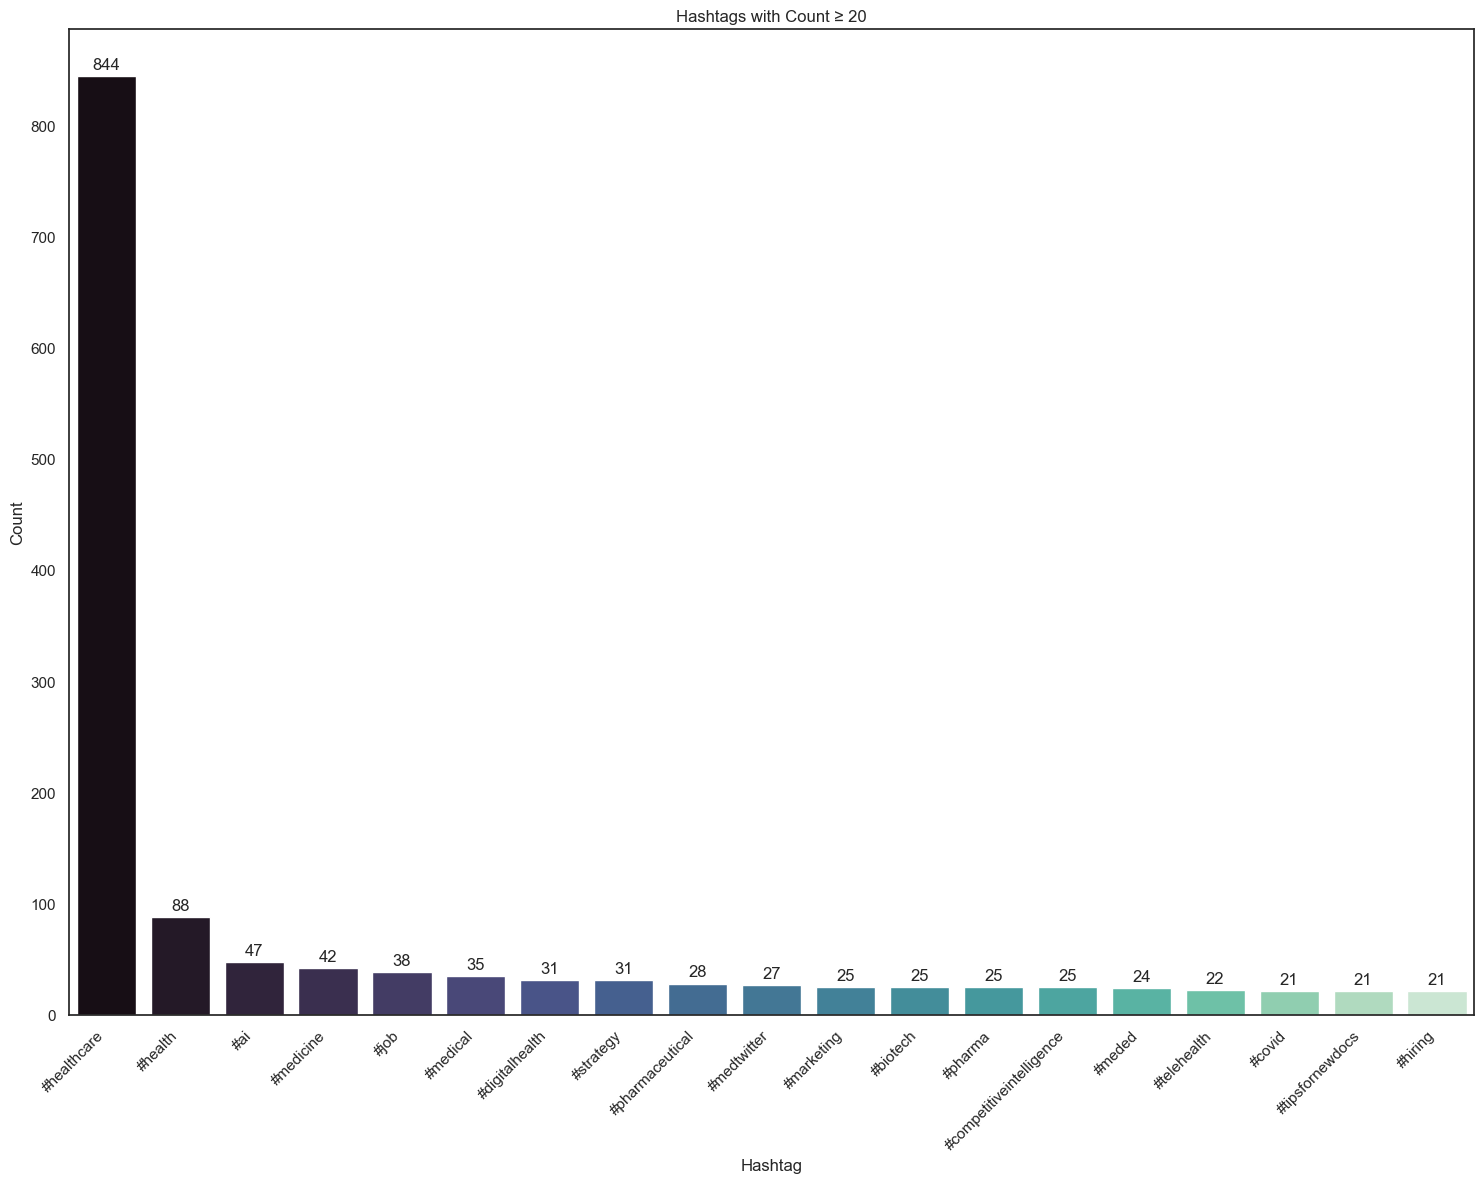

In [34]:
# Display hashtags where each hashtag appears 20 or more times
ax = sns.barplot(data=hashtags_filtered, x="hashtags", y="count", palette="mako")

# Add labels on top of each bar using the for loop below
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Hashtags with Count ≥ 20")
plt.xlabel("Hashtag")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Tweets.png")
plt.show()

#### Observation: The healthcare hashtag above appears 844 times dwarfing the remaining hashtags in the data set

## 4. Exploring the NHS appointment data sets with visuals

#### Question:   Create three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

#### Service setting

In [35]:
# Group the data by appointment month and service seeting
nc_ss = nc.groupby(['appointment_month', 'service_setting'])[['count_of_appointments']].sum().reset_index().copy()
nc_ss.head()

,appointment_month,service_setting,count_of_appointments
0,2021-08-01,Extended Access Provision,160927
1,2021-08-01,General Practice,21575852
2,2021-08-01,Other,449101
3,2021-08-01,Primary Care Network,432448
4,2021-08-01,Unmapped,1233843


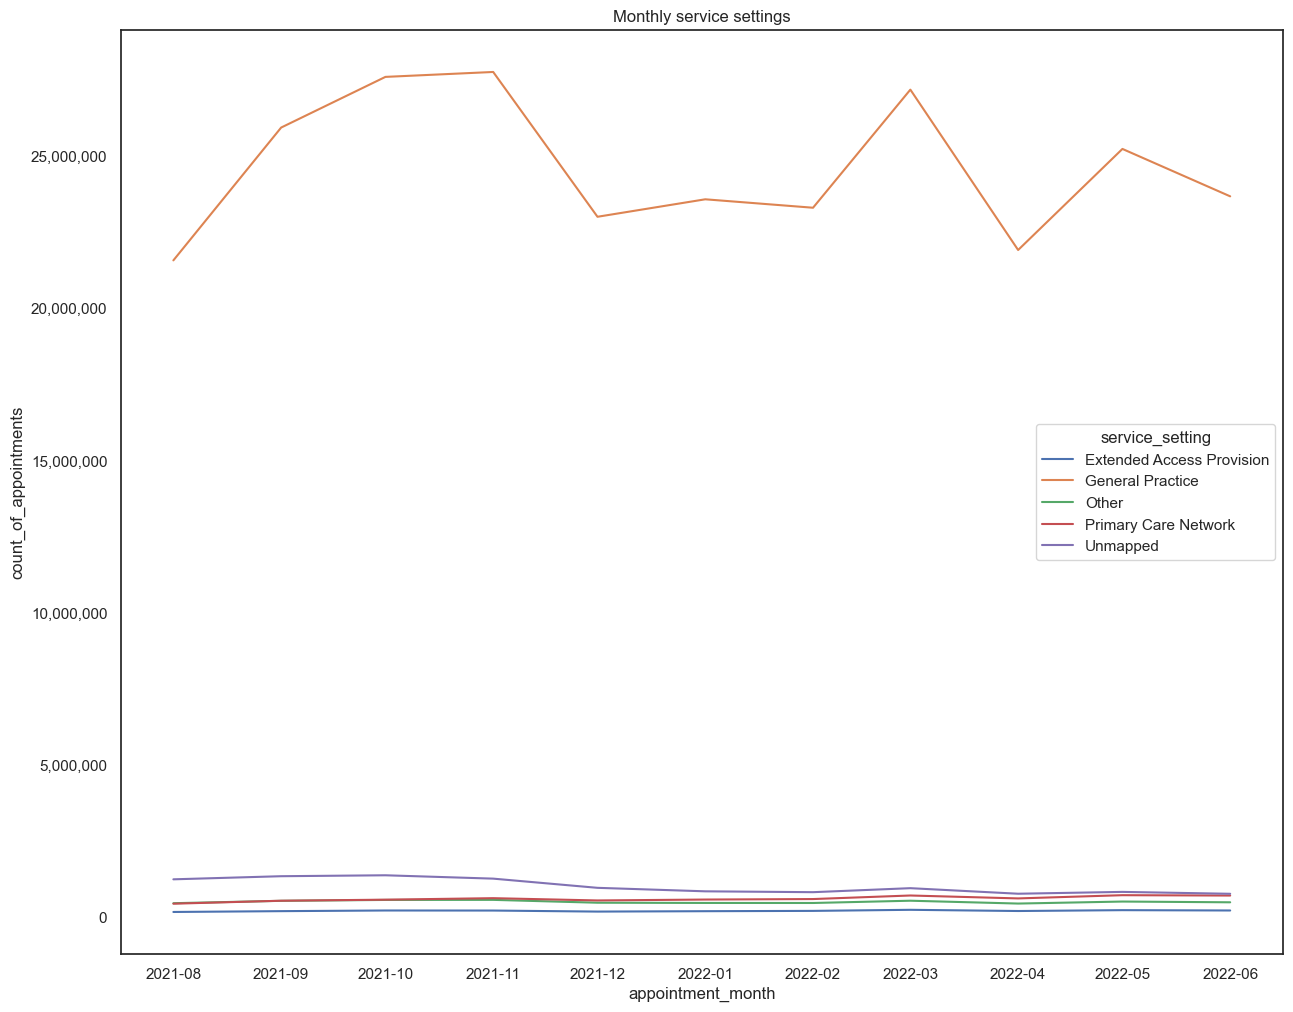

In [36]:
# Plot the appointments over the available date range, and review the service settings for months.
# Create a lineplot.
sns.lineplot(x='appointment_month', y='count_of_appointments', data=nc_ss, hue='service_setting')
plt.title('Monthly service settings')

# Format the y axis so that sum of appointments appear as comma separated whole numbers 
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))
plt.savefig("Monthly Service Settings Chart.png")

#### Observation: In the chart above most appointments take place in a GP surgery. The number of appointments seem to go up as we move from August into September, October and November. This could be due to months getting colder after summer and people especially children picking up illnesses when going back to school. But then the numbers decrease in December as schools are off and people are on Christmas breaks. Then there is another spike in March.   

#### Lets break the GP data down to ICB level to see if this trend happens for a few ICBs or all of them

In [37]:
# Filter the national categories data set to look at only GPs
nc_ss_GP = nc.loc[(nc['service_setting']=='General Practice')]

# Then group by month and ICBs
GP_grouped = nc_ss_GP.groupby(['appointment_month', 'icb_ons_code'])['count_of_appointments'].sum().reset_index()

# Pivot the data so that each ICB becomes a column
appointments_wide = GP_grouped.pivot(index='appointment_month', columns='icb_ons_code', values='count_of_appointments')
appointments_wide

icb_ons_code,E54000008,E54000010,E54000011,E54000013,E54000015,E54000018,E54000019,E54000022,E54000023,E54000024,...,E54000053,E54000054,E54000055,E54000056,E54000057,E54000058,E54000059,E54000060,E54000061,E54000062
appointment_month,,,,,,,,,,,,,,,,,,,,,
2021-08-01,1005799,414735,171370,304181,441626,365290,369087,437516,392291,351423,...,665955,1013117,463448,370826,943552,425923,251870,449334,536512,526520
2021-09-01,1244899,515898,209386,354071,524357,440004,453172,504913,489354,420359,...,824289,1186600,540049,426158,1169747,497224,312503,547470,635032,628400
2021-10-01,1318859,545319,229257,414869,526606,469849,466505,578425,508198,441351,...,827900,1252217,554564,473891,1244867,561726,341157,583596,695807,673547
2021-11-01,1302147,533022,235514,398896,558496,477390,472394,567159,499248,442043,...,834834,1285739,577344,456184,1270398,554745,357597,582569,697399,680522
2021-12-01,1059058,434281,191963,340488,461725,385693,391219,475733,415471,380638,...,696588,1101729,467611,375022,1047385,451301,292386,487208,585054,562534
2022-01-01,1091861,440623,193922,335949,475214,398260,394768,479602,425576,384990,...,724624,1103380,504485,385258,1075061,450876,303021,496648,597695,574014
2022-02-01,1076481,436800,198459,337390,468270,398739,392391,466421,414515,380816,...,704672,1073032,508327,372920,1075976,449454,292973,492741,593028,573146
2022-03-01,1267468,500951,232633,397193,544879,464675,452625,538892,479166,441197,...,829337,1264427,594028,440566,1280816,524003,340064,574806,696548,657250
2022-04-01,1008071,401452,190082,321580,434582,380761,368760,436833,391827,353302,...,668039,1037648,464944,353768,1019926,423287,272086,453593,568412,524153


In [38]:
# For each ICB do a percentage change month on month to see if the appointment numbers are increasing or decreasing compared to the previous month. 
# Sort by month
pct_change_wide = GP_grouped.sort_values([ 'appointment_month']).groupby('icb_ons_code')['count_of_appointments'].pct_change() * 100

# Add a new column pct_change to the GP_grouped DataFrame.
GP_grouped['pct_change'] = pct_change_wide

# Then pivot the data again, this tiem index by month, the columns are the ICBs and the values are the new column 'pct_change'
pct_change_wide = GP_grouped.pivot(index='appointment_month', columns='icb_ons_code', values='pct_change').round(2)
pct_change_wide

icb_ons_code,E54000008,E54000010,E54000011,E54000013,E54000015,E54000018,E54000019,E54000022,E54000023,E54000024,...,E54000053,E54000054,E54000055,E54000056,E54000057,E54000058,E54000059,E54000060,E54000061,E54000062
appointment_month,,,,,,,,,,,,,,,,,,,,,
2021-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-01,23.77,24.39,22.18,16.40,18.73,20.45,22.78,15.40,24.74,19.62,...,23.78,17.12,16.53,14.92,23.97,16.74,24.07,21.84,18.36,19.35
2021-10-01,5.94,5.70,9.49,17.17,0.43,6.78,2.94,14.56,3.85,4.99,...,0.44,5.53,2.69,11.20,6.42,12.97,9.17,6.60,9.57,7.18
2021-11-01,-1.27,-2.26,2.73,-3.85,6.06,1.60,1.26,-1.95,-1.76,0.16,...,0.84,2.68,4.11,-3.74,2.05,-1.24,4.82,-0.18,0.23,1.04
2021-12-01,-18.67,-18.52,-18.49,-14.64,-17.33,-19.21,-17.18,-16.12,-16.78,-13.89,...,-16.56,-14.31,-19.01,-17.79,-17.55,-18.65,-18.24,-16.37,-16.11,-17.34
2022-01-01,3.10,1.46,1.02,-1.33,2.92,3.26,0.91,0.81,2.43,1.14,...,4.02,0.15,7.89,2.73,2.64,-0.09,3.64,1.94,2.16,2.04
2022-02-01,-1.41,-0.87,2.34,0.43,-1.46,0.12,-0.60,-2.75,-2.60,-1.08,...,-2.75,-2.75,0.76,-3.20,0.09,-0.32,-3.32,-0.79,-0.78,-0.15
2022-03-01,17.74,14.69,17.22,17.73,16.36,16.54,15.35,15.54,15.60,15.86,...,17.69,17.84,16.86,18.14,19.04,16.59,16.07,16.65,17.46,14.67
2022-04-01,-20.47,-19.86,-18.29,-19.04,-20.24,-18.06,-18.53,-18.94,-18.23,-19.92,...,-19.45,-17.94,-21.73,-19.70,-20.37,-19.22,-19.99,-21.09,-18.40,-20.25


#### Observation: As expected there is big increase in percentages in September compared to August across all ICBs. August is summer holiday time so fewer appointments. But it picks up in September / October as schools open and people go back to work picking up illnesses as the weather gets colder. The percentage increases slightly in October and November as well but then there is big drop in the percentages in December across all ICBs. This could be the Christmas holidays and fewer appointments. Then it increases again in March and falls in April.

#### As GP appointments take up a large proportion, lets exclude them and look at the remaining service settings

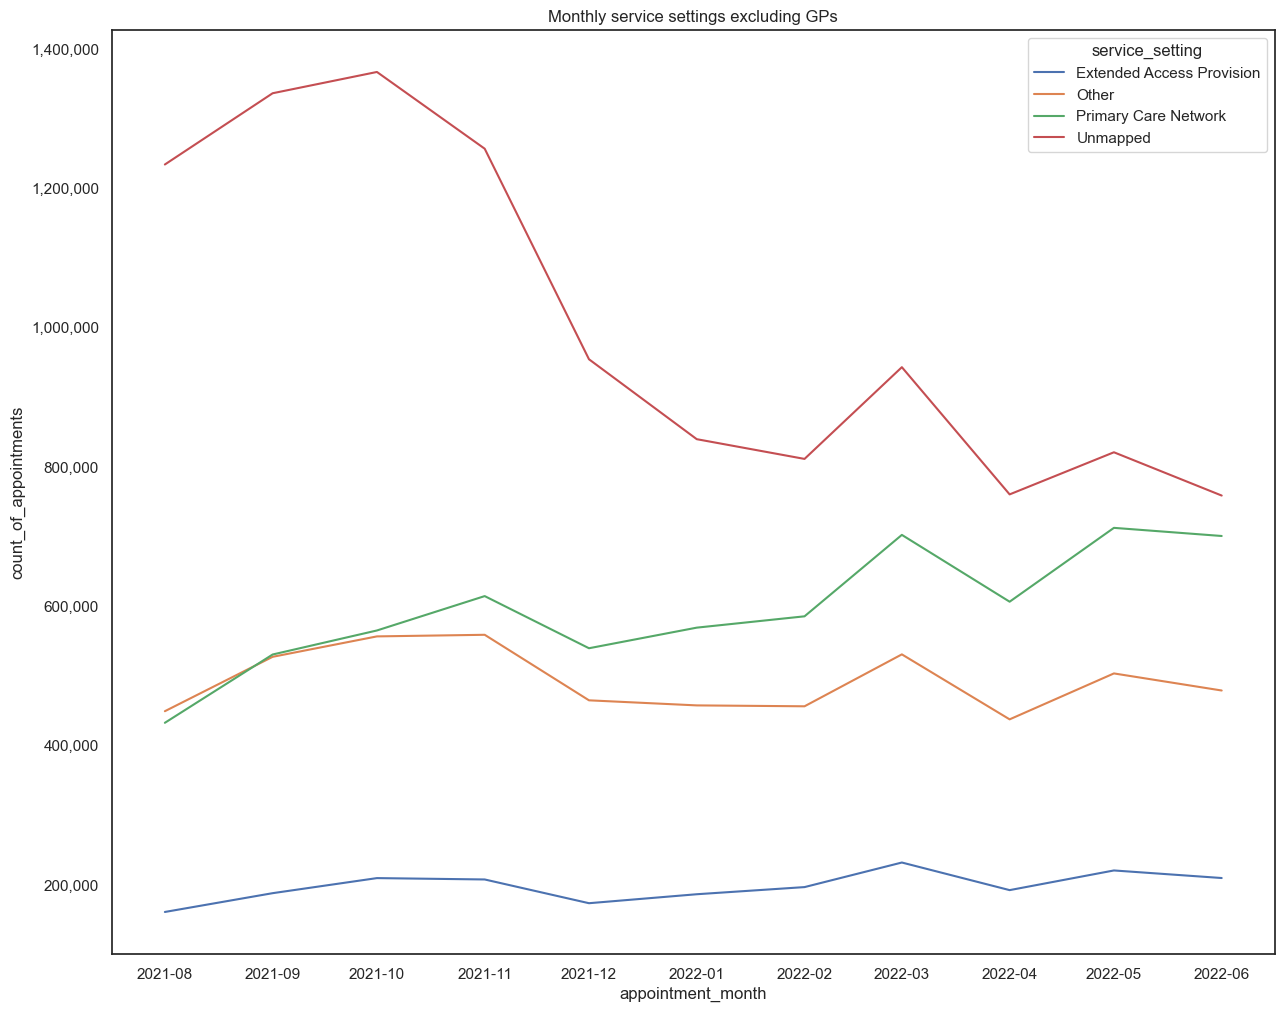

In [39]:
# Exclude GPs from the dataset
nc_ss_exlc_GP = nc_ss.loc[(nc_ss['service_setting']!='General Practice')]

# Plot again using new dataset
sns.lineplot(x='appointment_month', y='count_of_appointments', data=nc_ss_exlc_GP, hue='service_setting')
plt.title('Monthly service settings excluding GPs')

# Format the y axis so that sum of appointments appear as comma separated whole numbers 
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))
plt.savefig("Monthly Service Settings excluding GP Chart.png")

#### Observation: In the above chart unmapped is most prominent but these could be due to no categoires being recorded. But these are gradually decreasing which is a good sign as it means more and more are being mapped correctly. For the other settings 'Primary Care Network' and 'Extended Access Provision' there seem to be spikes in appointments in Nov-21 and then again in March and May-22. I think spreading out appointments to other months would reduce the workload on the NHS

#### Context Type

In [40]:
# Group the data by appointment month and context type
nc_ct = nc.groupby(['appointment_month', 'context_type'])[['count_of_appointments']].sum().reset_index().copy()
nc_ct.head()

,appointment_month,context_type,count_of_appointments
0,2021-08-01,Care Related Encounter,20255235
1,2021-08-01,Inconsistent Mapping,2363093
2,2021-08-01,Unmapped,1233843
3,2021-09-01,Care Related Encounter,24404251
4,2021-09-01,Inconsistent Mapping,2782135


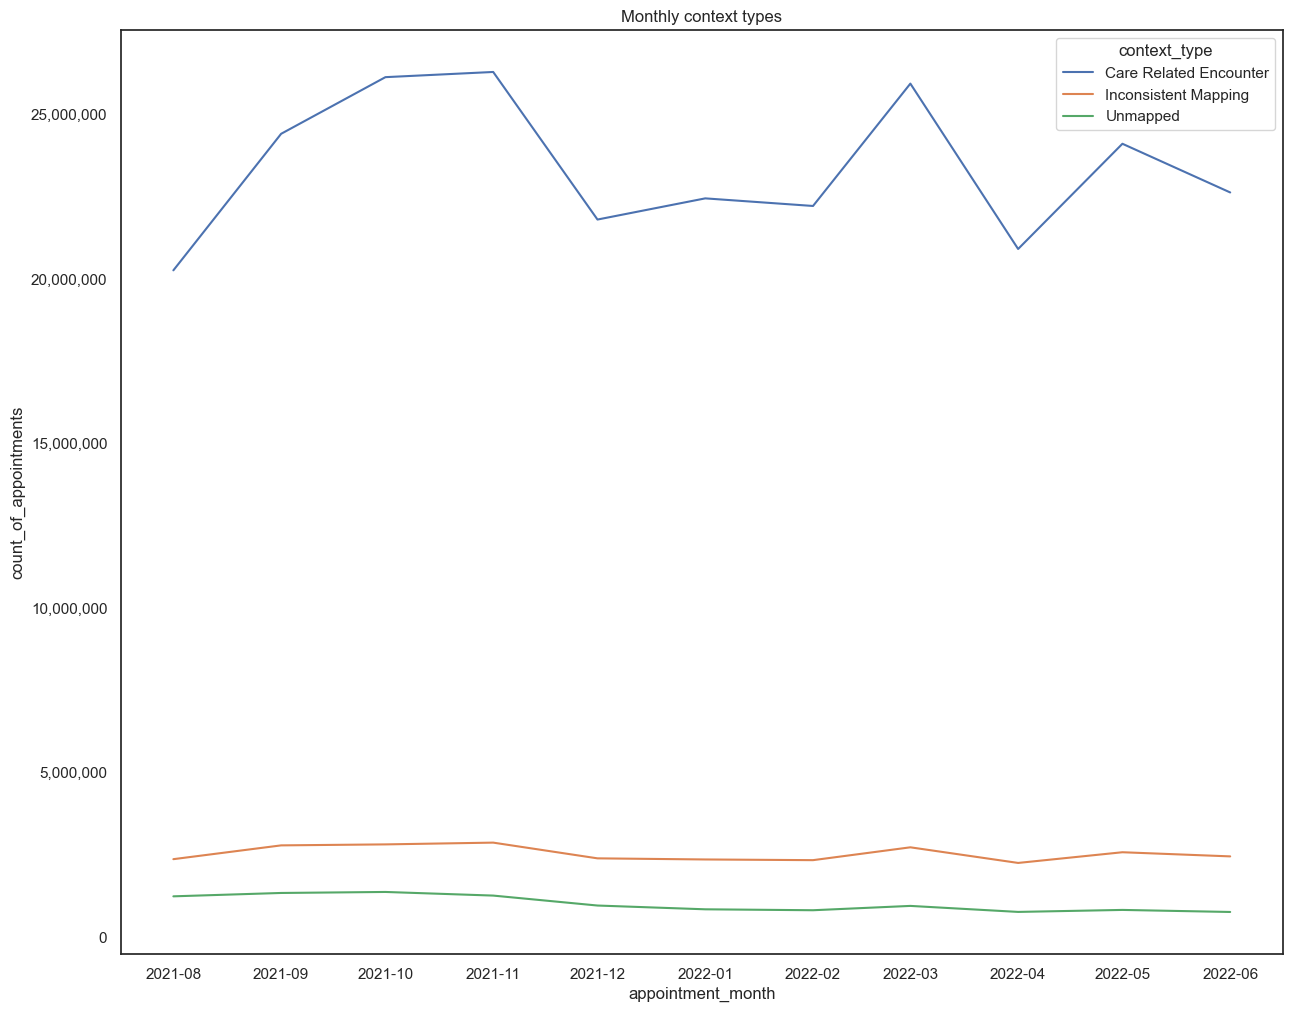

In [41]:
# Plot the appointments over the available date range, and review the context types for months.
# Create a lineplot.
sns.lineplot(x='appointment_month', y='count_of_appointments', data=nc_ct, hue='context_type')
plt.title('Monthly context types')

# Format the y axis so that sum of appointments appear as comma separated whole numbers 
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))
plt.savefig("Monthly Context Type Chart.png")

#### Observation: In the chart above care related encounters seem to gradually increase from Sep-Nov-21 and then fall in December. This follows a similar pattern to the service settings dataset

#### National categories

In [42]:
# Group the data by appointment month and national categories
nc_nc = nc.groupby(['appointment_month', 'national_category'])[['count_of_appointments']].sum().reset_index().copy()
nc_nc.head()

,appointment_month,national_category,count_of_appointments
0,2021-08-01,Care Home Needs Assessment & Personalised Care and Support Planning,29676
1,2021-08-01,Care Home Visit,47583
2,2021-08-01,Clinical Triage,3704207
3,2021-08-01,General Consultation Acute,4280920
4,2021-08-01,General Consultation Routine,7756045


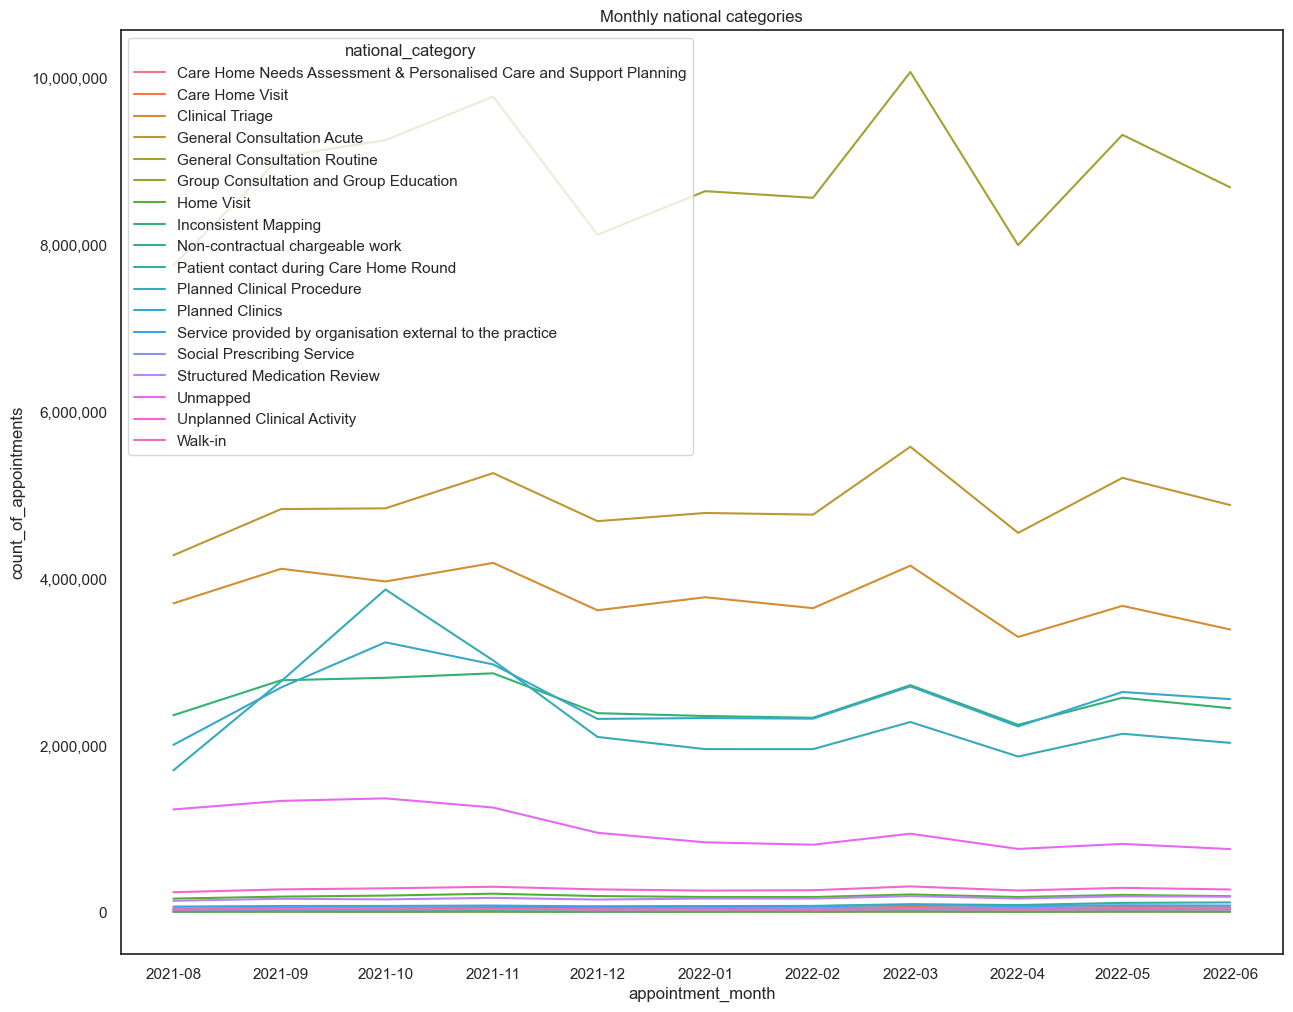

In [43]:
# Plot the appointments over the available date range, and review the national categories for months.
# Create a lineplot.
sns.lineplot(x='appointment_month', y='count_of_appointments', data=nc_nc, hue='national_category')
plt.title('Monthly national categories')

# Format the y axis so that sum of appointments appear as comma separated whole numbers 
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))
plt.savefig("Monthly National Categories Chart.png")

#### Observation: In the above chart General Consultation Routine and General Consultation Acute account for the top two categories. There are spikes in Nov-21 and Mar-22

### Question : Create four visualisations indicating the number of appointments for service setting per season. The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

#### **Summer (June to August 2021):**

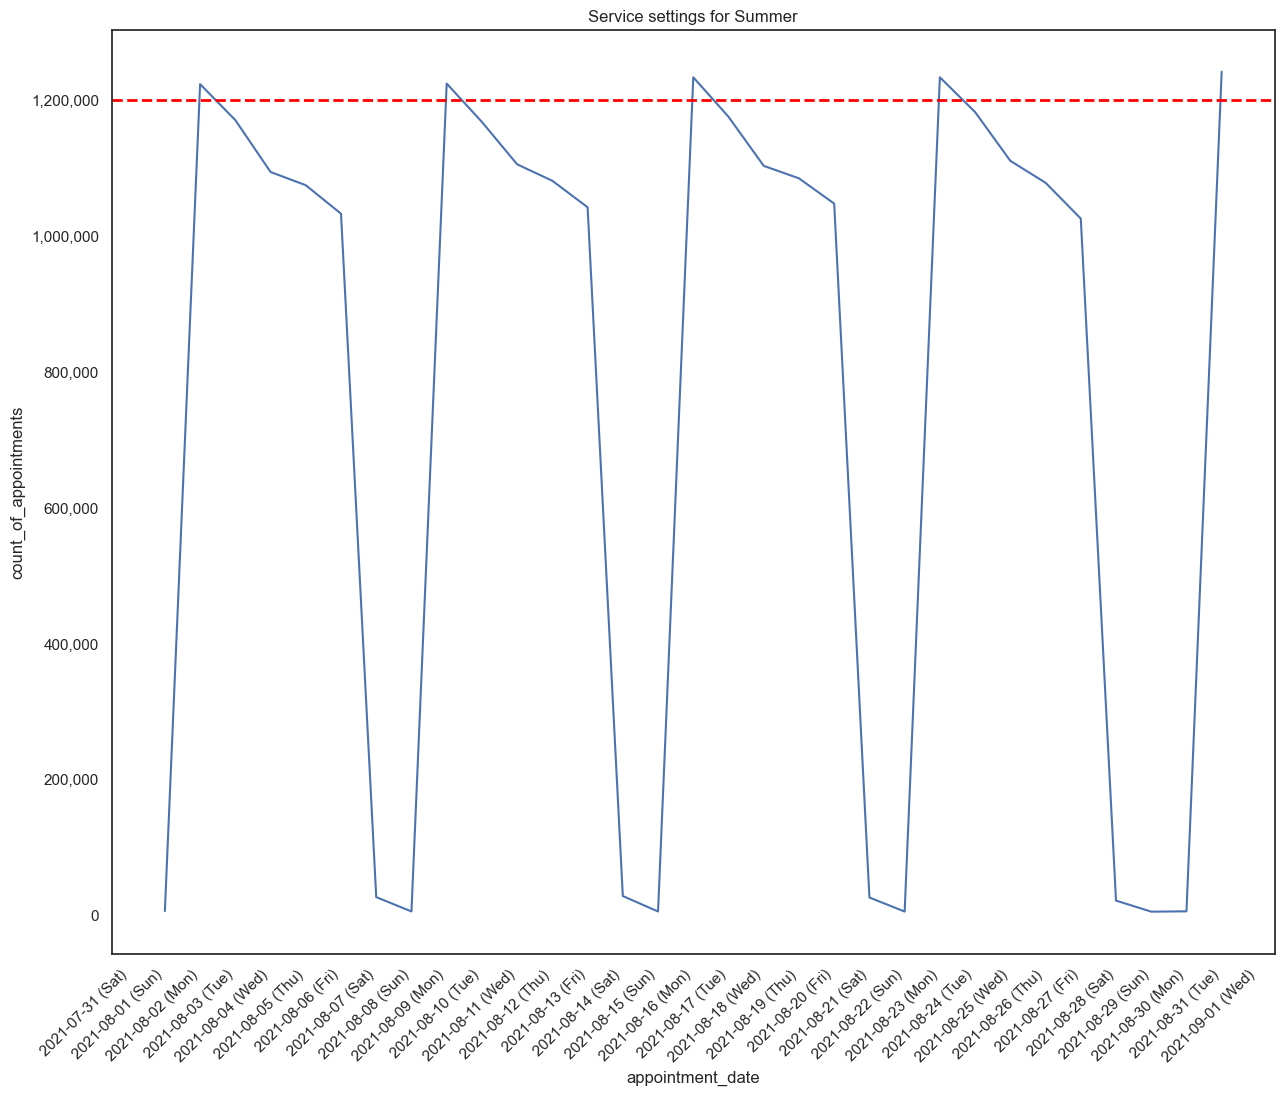

In [44]:
# Look at August 2021 in more detail to allow a closer look.
# Create a lineplot.

# Filter the data by Aug-21 
nc_summer_sc = nc[nc['appointment_month']=='2021-08']

#Group the data by date and appointments
nc_summer_sc = nc_summer_sc.groupby(['appointment_date'])[['count_of_appointments']].sum().reset_index().copy()

#Create a line plot 
sns.lineplot(x='appointment_date', y='count_of_appointments', data=nc_summer_sc)
plt.title('Service settings for Summer')

# Horizontal threshold line set at maximum aapointments per day of 1.2 million
plt.axhline(y=1_200_000, color='red', linestyle='--', linewidth=2, label='Threshold (1,200,000)')
 
# Format the y-axis to absolute values and comma separated
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))

# Show every day on the x-axis
plt.gca().xaxis.set_major_locator(mdates.DayLocator())  # DayLocator() shows a tick for each day 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d (%a)'))  # Format the day as year, month, day and day of week
plt.xticks(rotation=45, ha='right')
plt.savefig("Summer.png")
plt.show()


#### Observation: The chart above shows the appointments for each day in August. It appears that the 1.2 million daily NHS appointment threshold is breached on Mondays. Whereas the numbers fall sharply on weekends. People with illnesses over weekends try to book appoinments on Mondays.

#### **Autumn (September to November 2021):**

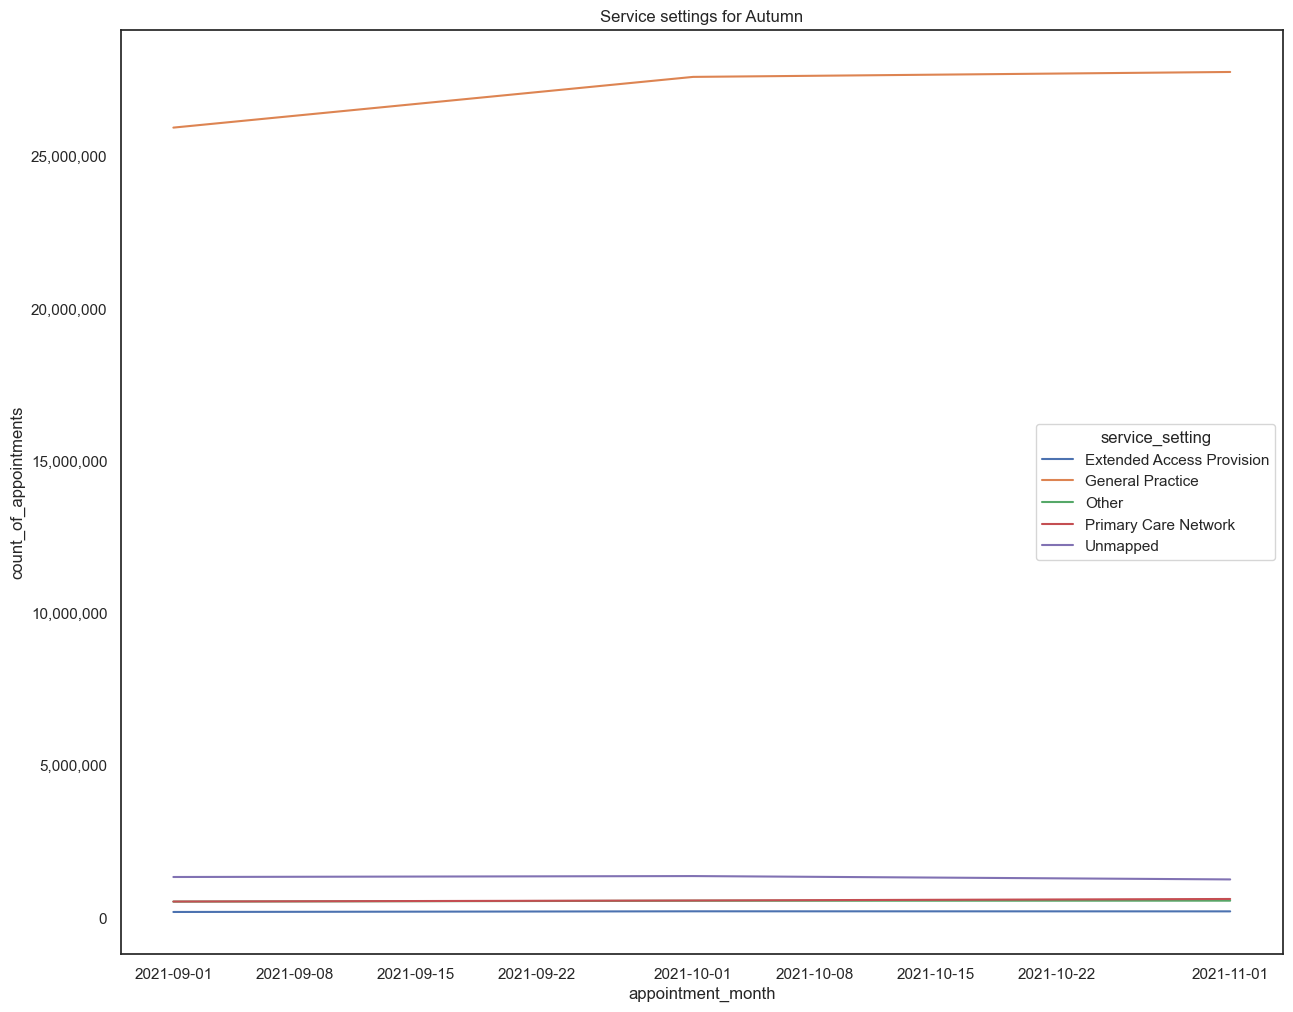

In [45]:
# Look at September to November 2021 in more detail to allow a closer look.
# Create a lineplot.
#plt.figure(figsize=(18, 6))

nc_autumn_sc = nc[nc['appointment_month'].isin(['2021-09', '2021-10', '2021-11'])]

nc_autumn_sc_grouped = nc_autumn_sc.groupby(['appointment_month', 'service_setting'])[['count_of_appointments']].sum().reset_index().copy()

sns.lineplot(x='appointment_month', y='count_of_appointments', data=nc_autumn_sc_grouped, hue='service_setting')
plt.title('Service settings for Autumn')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))

#### Observation: November appears to be the busiest month in Autumn. Lets break it down to see the information by day

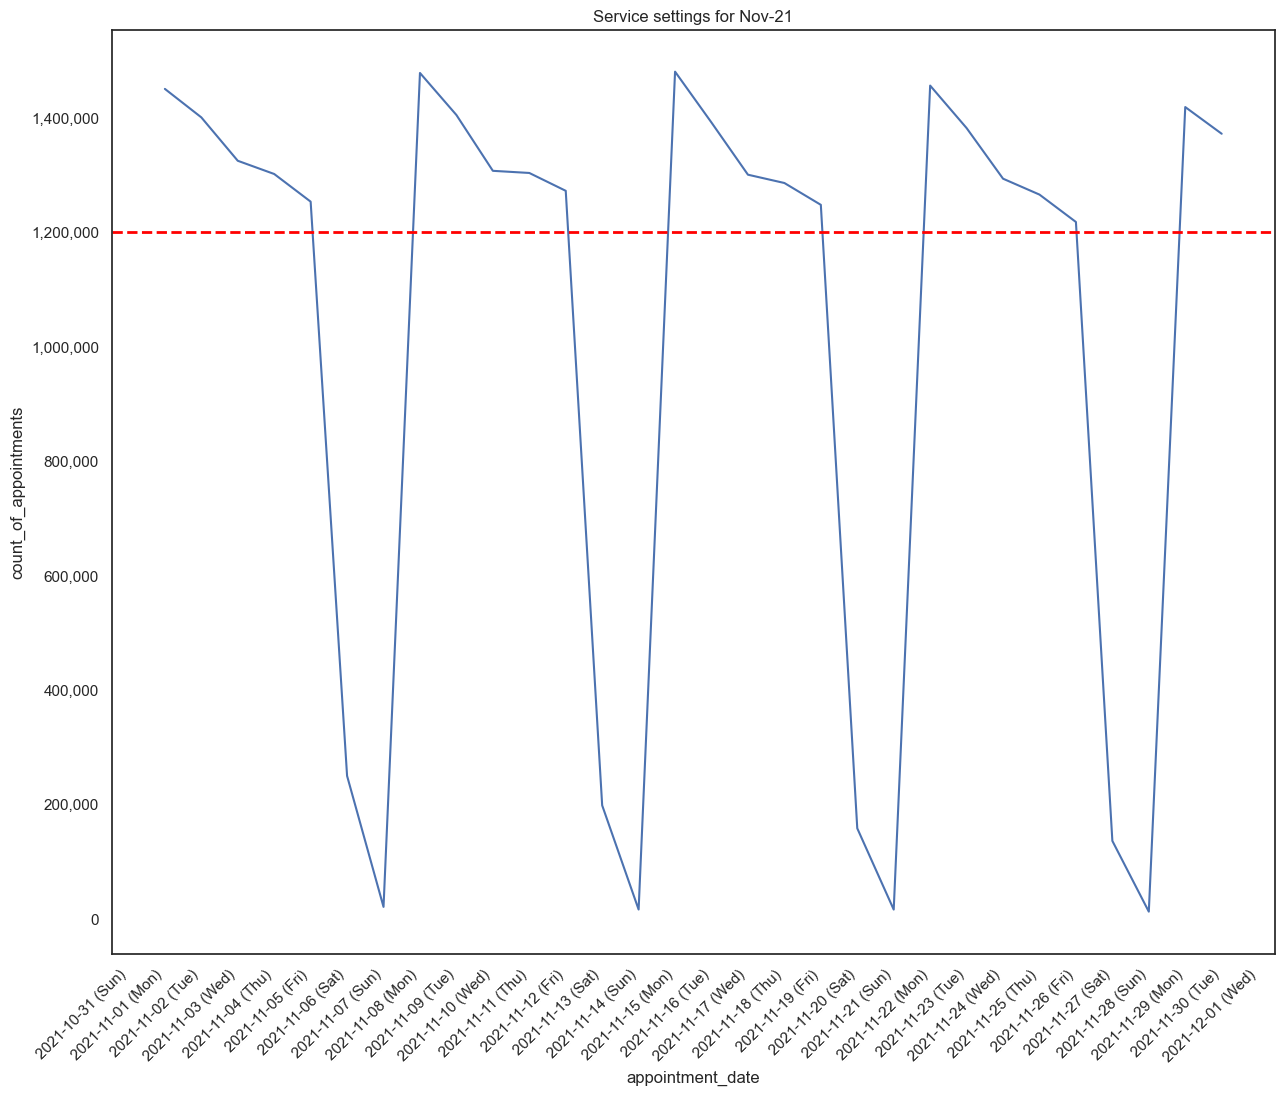

In [61]:
# Look at Autumn 2021 in more detail to allow a closer look.
# Create a lineplot.
#plt.figure(figsize=(18, 6))

#Group the data by date and appointments
nc_Nov11_sc = nc[nc['appointment_month']=='2021-11']
nc_autumn_sc = nc_Nov11_sc.groupby(['appointment_date'])[['count_of_appointments']].sum().reset_index().copy()

#Create a line plot 
sns.lineplot(x='appointment_date', y='count_of_appointments', data=nc_autumn_sc)
plt.title('Service settings for Nov-21')

# Horizontal threshold line set at maximum aapointments per day of 1.2 million
plt.axhline(y=1_200_000, color='red', linestyle='--', linewidth=2, label='Threshold (1,200,000)')
 
# Format the y-axis to absolute values and comma separated
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))

# Show every day on the x-axis
plt.gca().xaxis.set_major_locator(mdates.DayLocator())  # DayLocator() shows a tick for each day 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d (%a)'))  # Format the day as year, month, day and day of week
plt.xticks(rotation=45, ha='right')
plt.savefig("Autumn.png")
plt.show()

#### Observation: It appears that in November 2021 nearly every single day (apart from weekends) breached the 1.2 million per day NHS appointments threshold

### Winter (December-21 to February-22)

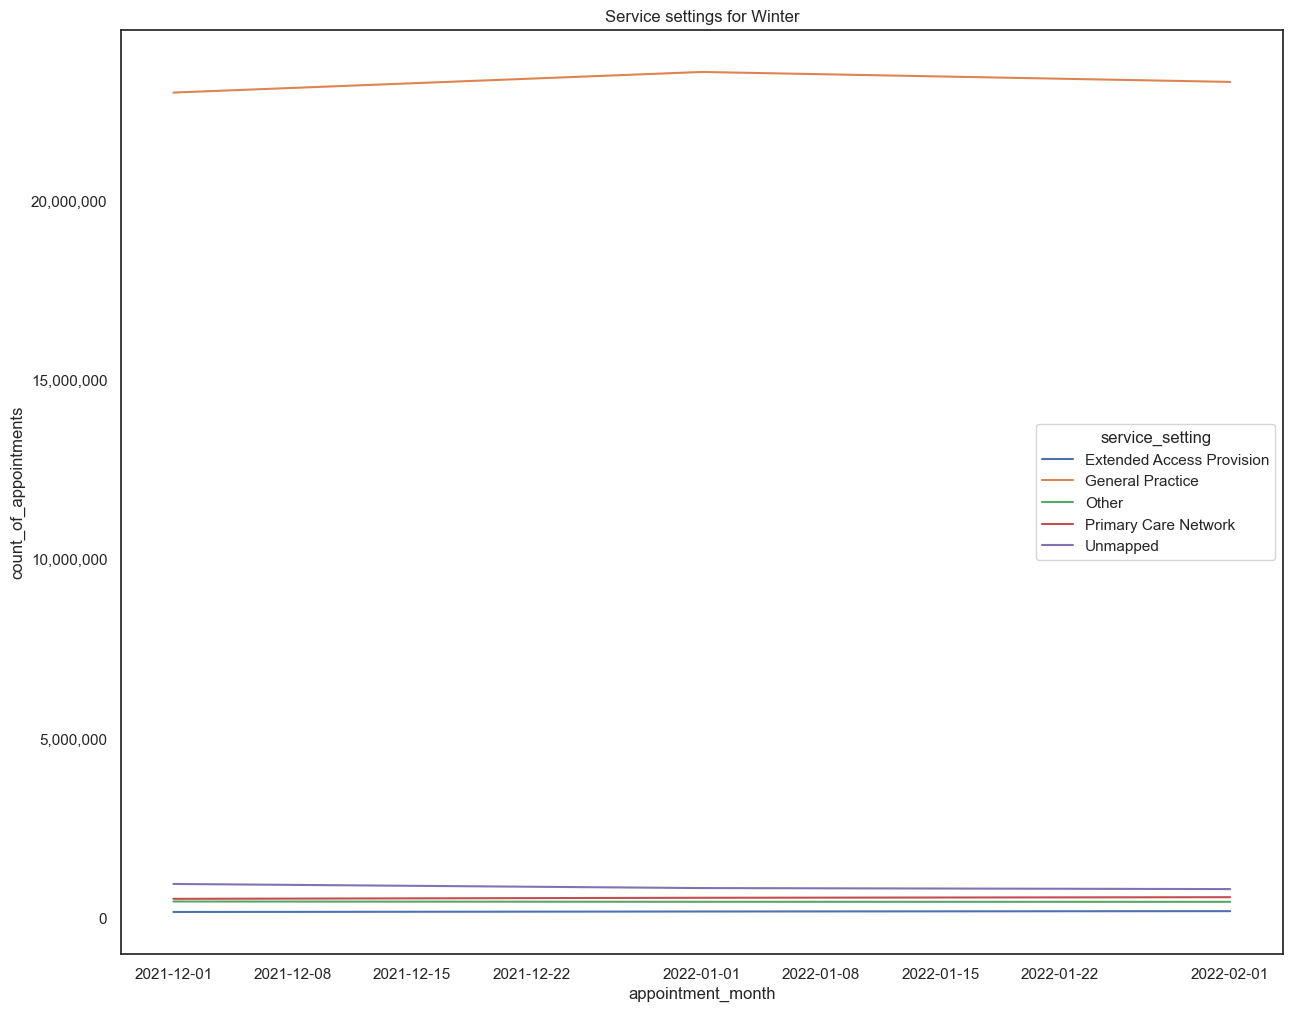

In [47]:
# Look at December-21 to February 2022 in more detail to allow a closer look.
# Create a lineplot.
#plt.figure(figsize=(18, 6))

nc_winter_sc = nc[nc['appointment_month'].isin(['2021-12', '2022-01', '2022-02'])]

nc_winter_sc_grouped = nc_winter_sc.groupby(['appointment_month', 'service_setting'])[['count_of_appointments']].sum().reset_index().copy()

sns.lineplot(x='appointment_month', y='count_of_appointments', data=nc_winter_sc_grouped, hue='service_setting')
plt.title('Service settings for Winter')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))

### Spring (March-22 to May-22)

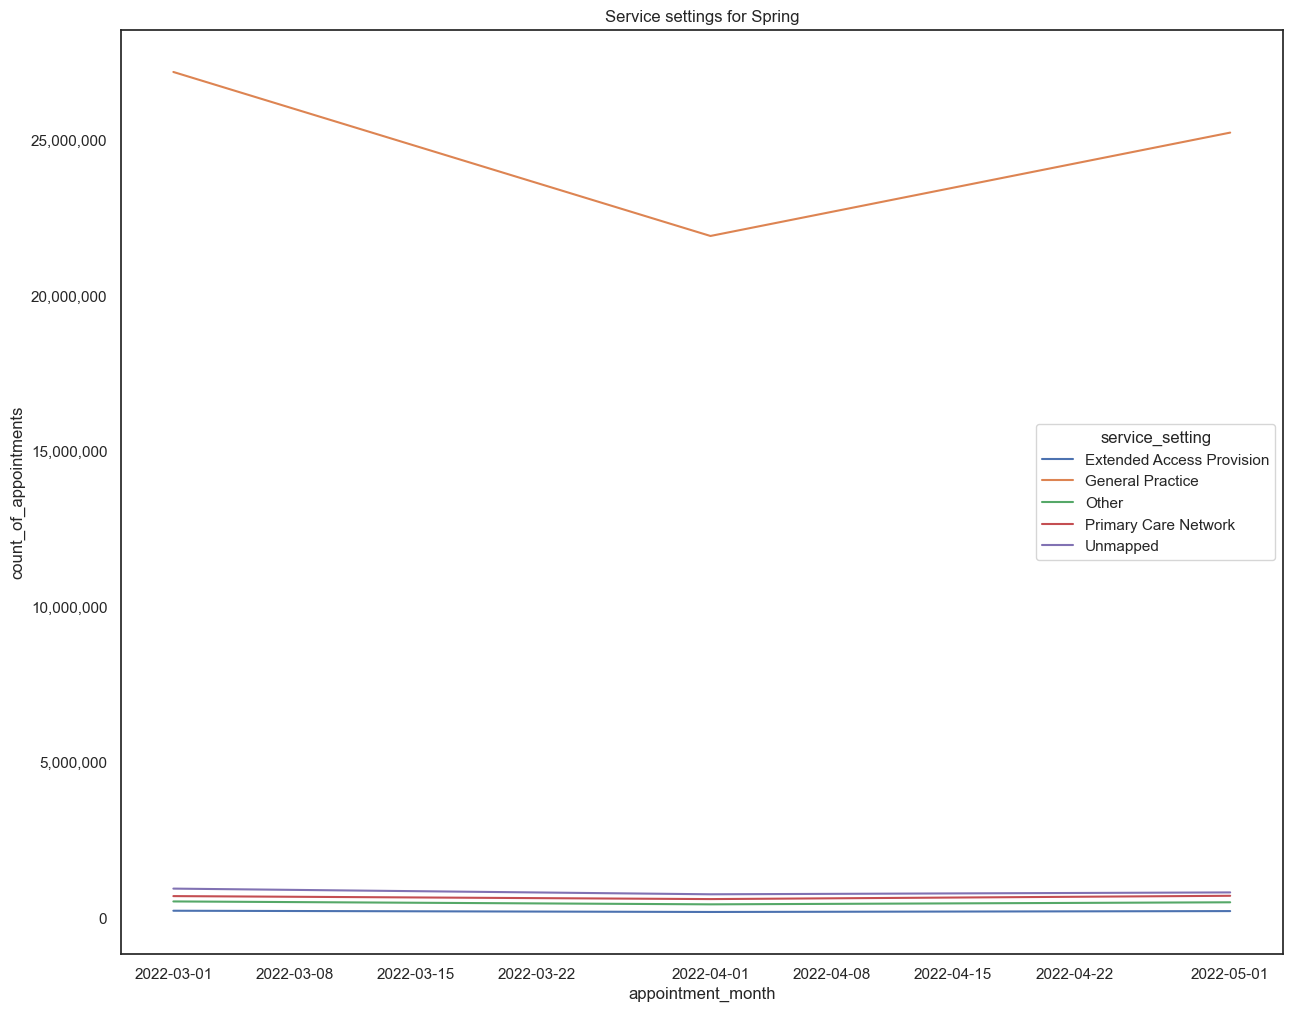

In [48]:
# Look at March 2022 to May 2022 in more detail to allow a closer look.
# Create a lineplot.
#plt.figure(figsize=(18, 6))

nc_spring_sc = nc[nc['appointment_month'].isin(['2022-03', '2022-04', '2022-05'])]

nc_spring_sc_grouped = nc_spring_sc.groupby(['appointment_month', 'service_setting'])[['count_of_appointments']].sum().reset_index().copy()

sns.lineplot(x='appointment_month', y='count_of_appointments', data=nc_spring_sc_grouped, hue='service_setting')
plt.title('Service settings for Spring')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))

## 5. Make recommendations to the NHS. 

### **Question :** Should the NHS start looking at increasing staff levels? 

In [49]:
# Filter the appointments regional dataset to look at dates from Aug-21 onwards
ar_filtered =ar[ar['appointment_month']>='2021-08']

# Group the dataset by month and appointments
ar_Daily_utilisation = ar_filtered.groupby(['appointment_month'])[['count_of_appointments']].sum()

# Create a daily utilisation column by dividing the total appointments each month by 30
ar_Daily_utilisation['Daily Utilisation'] = (ar_Daily_utilisation['count_of_appointments'] / 30).round(0)

# Create a column to show the daily NHS appointments capacity of 1.2million for each month
ar_Daily_utilisation['NHS Avg Daily Appt Limit'] = 1200000

# Create a column to work out the percentage utilisation based om the daily count divided by the NHS daily capacity of 1.2m
ar_Daily_utilisation['Percentage Daily Utilisation'] = ((ar_Daily_utilisation['Daily Utilisation'] / ar_Daily_utilisation['NHS Avg Daily Appt Limit']) * 100).round(0)

ar_Daily_utilisation

,count_of_appointments,Daily Utilisation,NHS Avg Daily Appt Limit,Percentage Daily Utilisation
appointment_month,,,,
2021-08-01,23852171,795072.0,1200000,66.0
2021-09-01,28522501,950750.0,1200000,79.0
2021-10-01,30303834,1010128.0,1200000,84.0
2021-11-01,30405070,1013502.0,1200000,84.0
2021-12-01,25140776,838026.0,1200000,70.0
2022-01-01,25635474,854516.0,1200000,71.0
2022-02-01,25355260,845175.0,1200000,70.0
2022-03-01,29595038,986501.0,1200000,82.0
2022-04-01,23913060,797102.0,1200000,66.0


#### Observation: As can be seen above in the percentage daily utlisation column, the NHS daily limit of 1.2m is never breached, i.e. the figure is always below 100% per month. Even though it increases to 84% in October and November. I think the reason it does not breach the maximum capacity is because there are days in the month where it breaches capacity and on some days it does not. So the overall average is smoothed out and remains below the maximum NHS limit. However, as we saw in the exploratory analysis there are days in August and November where the NHS daily is breached particularly on Mondays.

#### I would recommend that the NHS spread out these appointments. Many surgeries have limited appointments and operate a "same-day" booking system, and there is an intense rush of calls when lines open on Monday mornings. It is advisable to spread them out to later in the week. It would also be good to increase GP surgeries to cope with the increasing population.

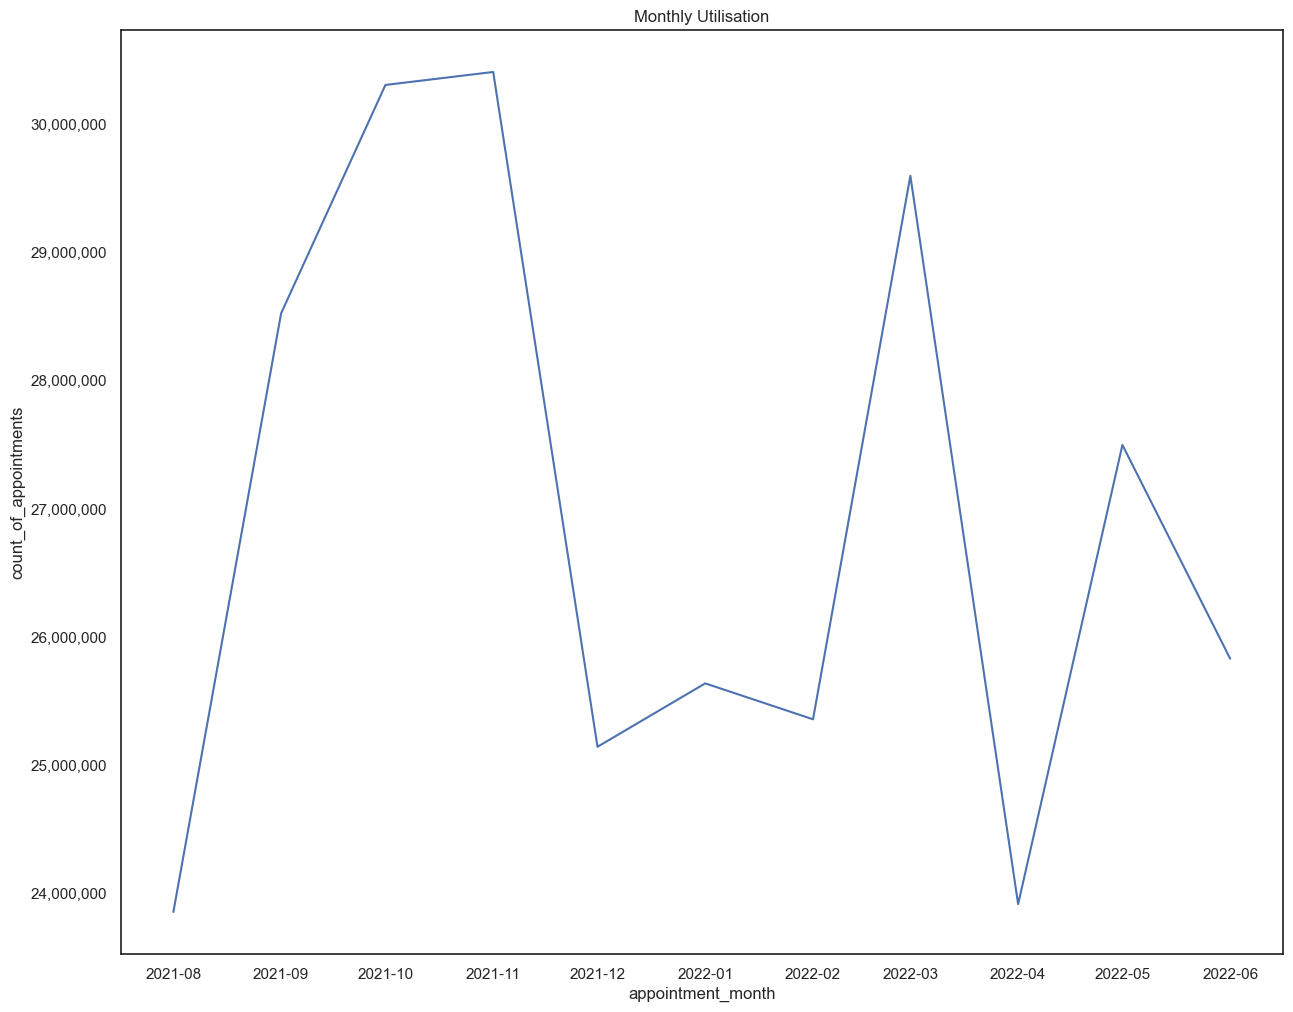

In [50]:
# Line plot below shows appointments booked per month
sns.lineplot(x='appointment_month', y='count_of_appointments', data=ar_Daily_utilisation)
plt.title('Monthly Utilisation')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))

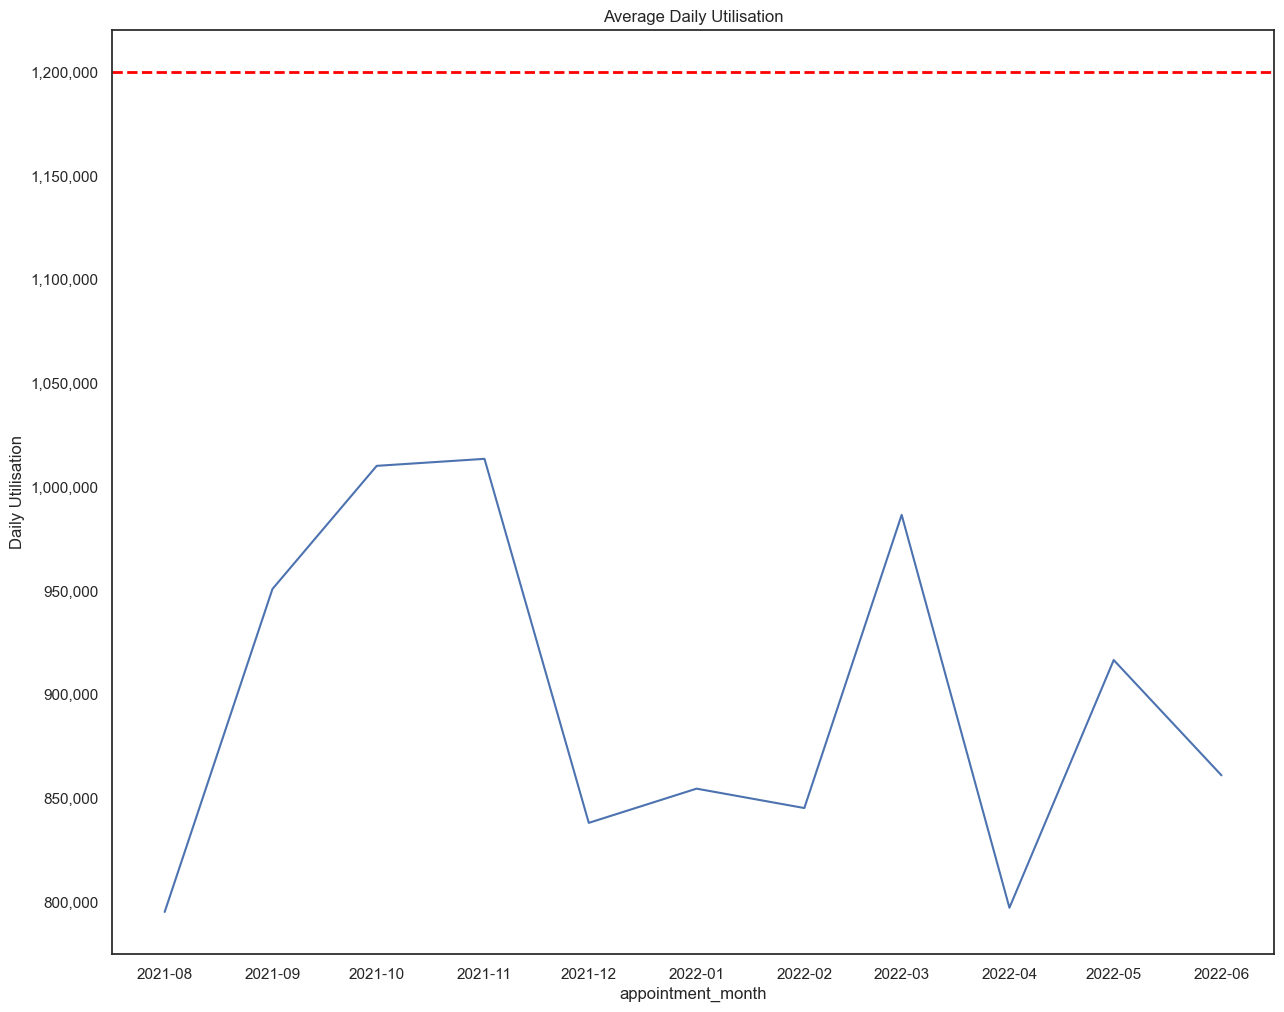

In [51]:
# Line plot below shows the average daily utilisation per month
sns.lineplot(x='appointment_month', y='Daily Utilisation', data=ar_Daily_utilisation)
plt.title('Average Daily Utilisation')

# Horizontal threshold line set at maximum aapointments per day of 1.2 million
plt.axhline(y=1_200_000, color='red', linestyle='--', linewidth=2, label='Threshold (1,200,000)')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))

### Question : How do the healthcare professional types differ over time?

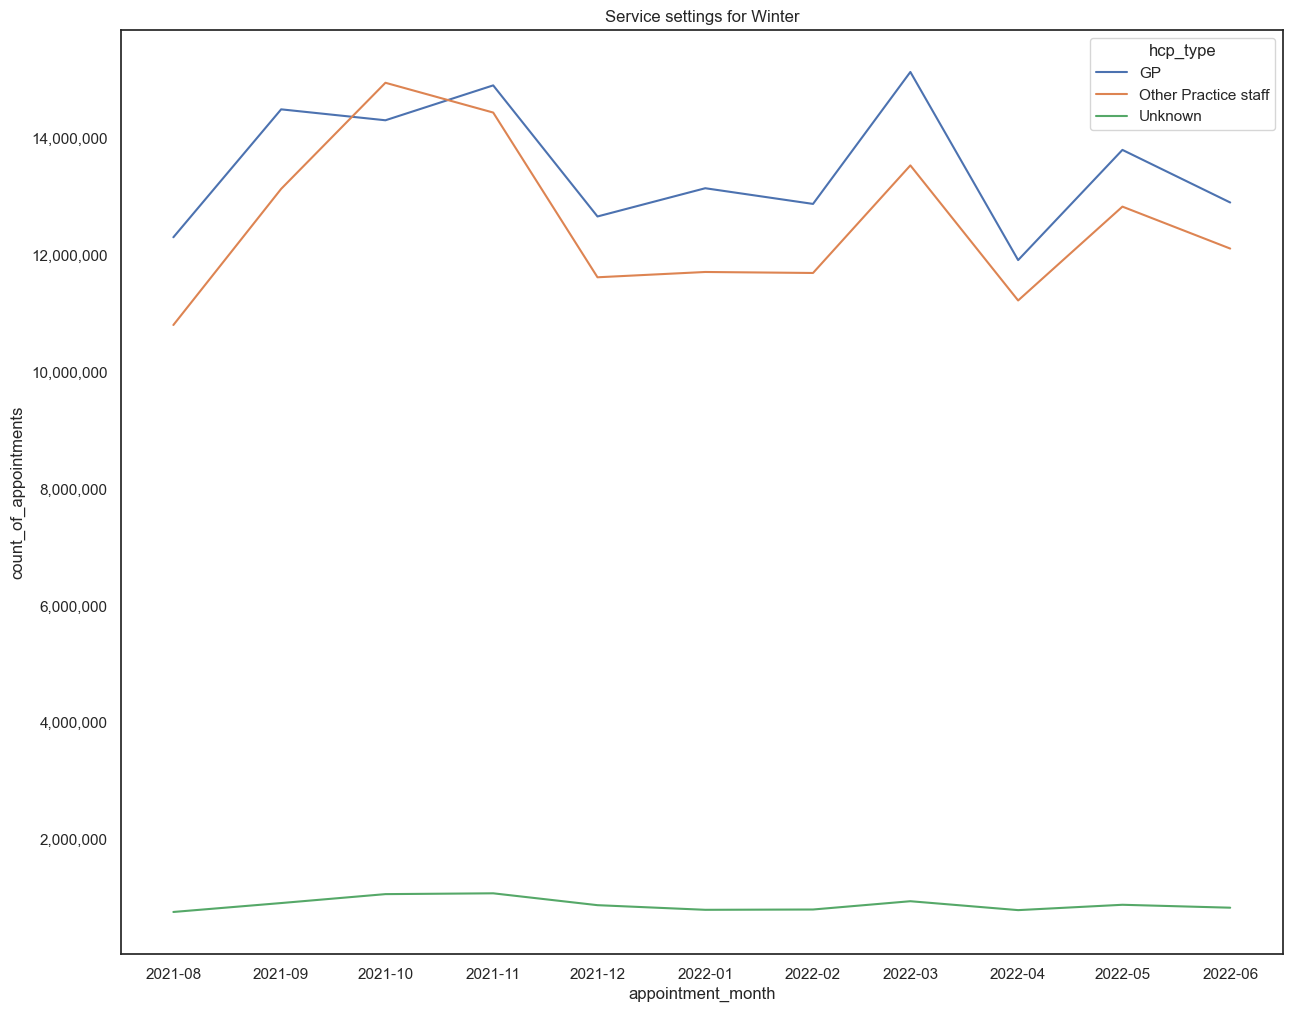

In [52]:
# Group the dataset by month and appointments
ar_Daily_utilisation = ar_filtered.groupby(['appointment_month', 'hcp_type'])[['count_of_appointments']].sum().reset_index()

#Plot the data using a line chart
sns.lineplot(x='appointment_month', y='count_of_appointments', data=ar_Daily_utilisation, hue='hcp_type')
plt.title('Service settings for Winter')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))
plt.savefig("HCP.png")

#### Observation: Above in Oct-21 'Other Practice Staff' overtook GPs for the most number of appointments booked. There is not enough granularity in the data to show which practice staff were the busiest. I recommend the NHS to spread out these appointments to other months so as to avoid over booking in October. Also show the data in more granular detail to see if there are staff shortages in a particular NHS profession.  

### **Question 3:** Are there significant changes in whether or not visits are attended?

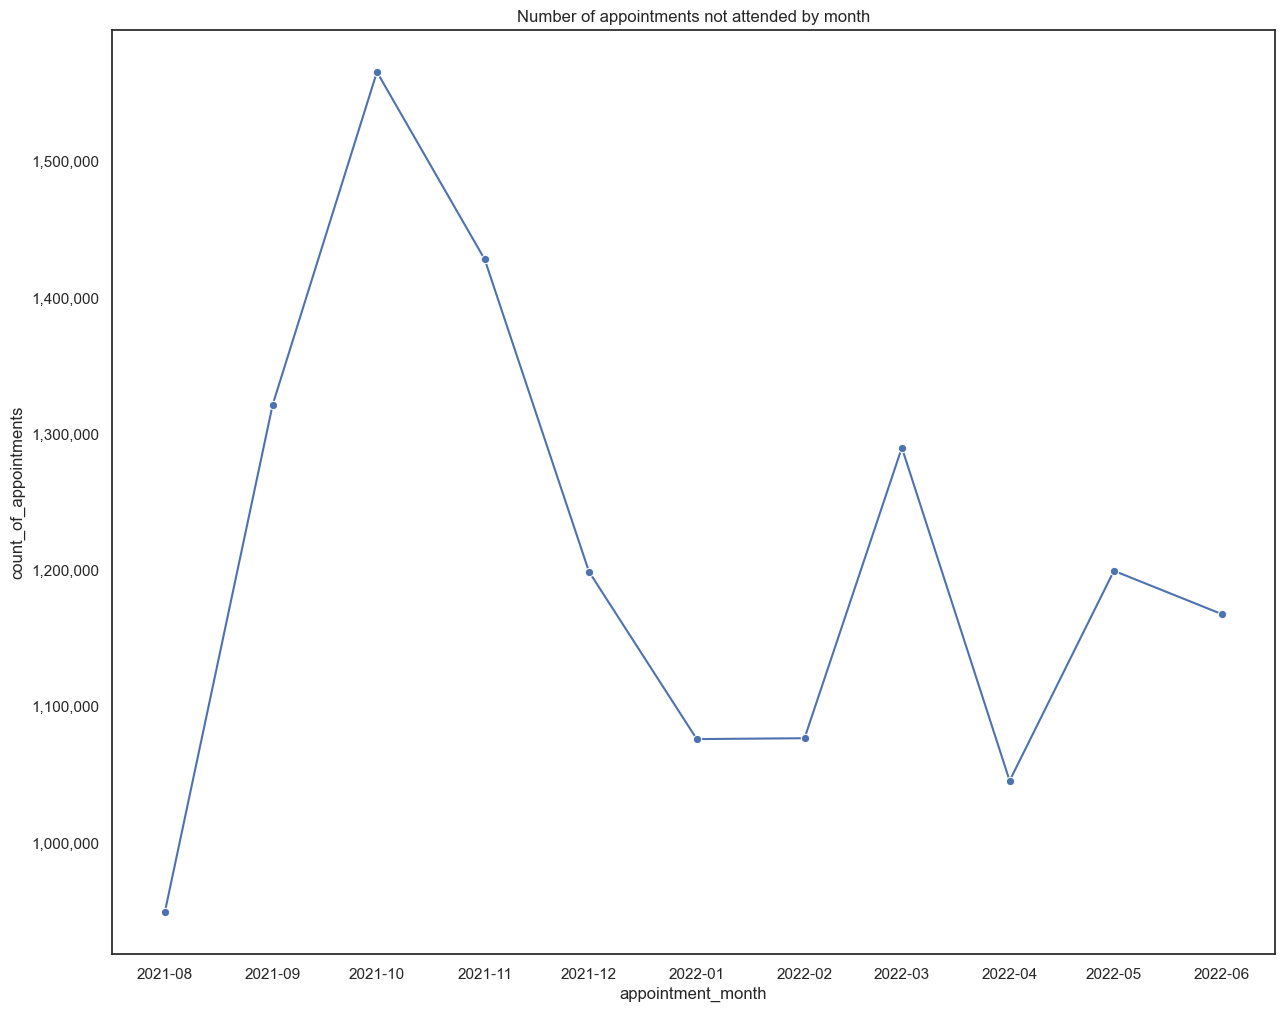

In [53]:
#Filter the dataset to show appointments not attneded
ar_DNA =ar_filtered[ar_filtered['appointment_status']=='DNA']

# Group the dataset by month and appointments
ar_DNA_Grouped = ar_DNA.groupby(['appointment_month'])[['count_of_appointments']].sum().reset_index()

# Plot the data
sns.lineplot(x='appointment_month', y='count_of_appointments', data=ar_DNA_Grouped, marker='o')
plt.title('Number of appointments not attended by month')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))
plt.savefig("DNA.png")

#### Observation: Above there is a spike in DNA in Oct-21 but since then there is a general decline in the number of missed appointments each month. Lets break this down further by healthcare professional type

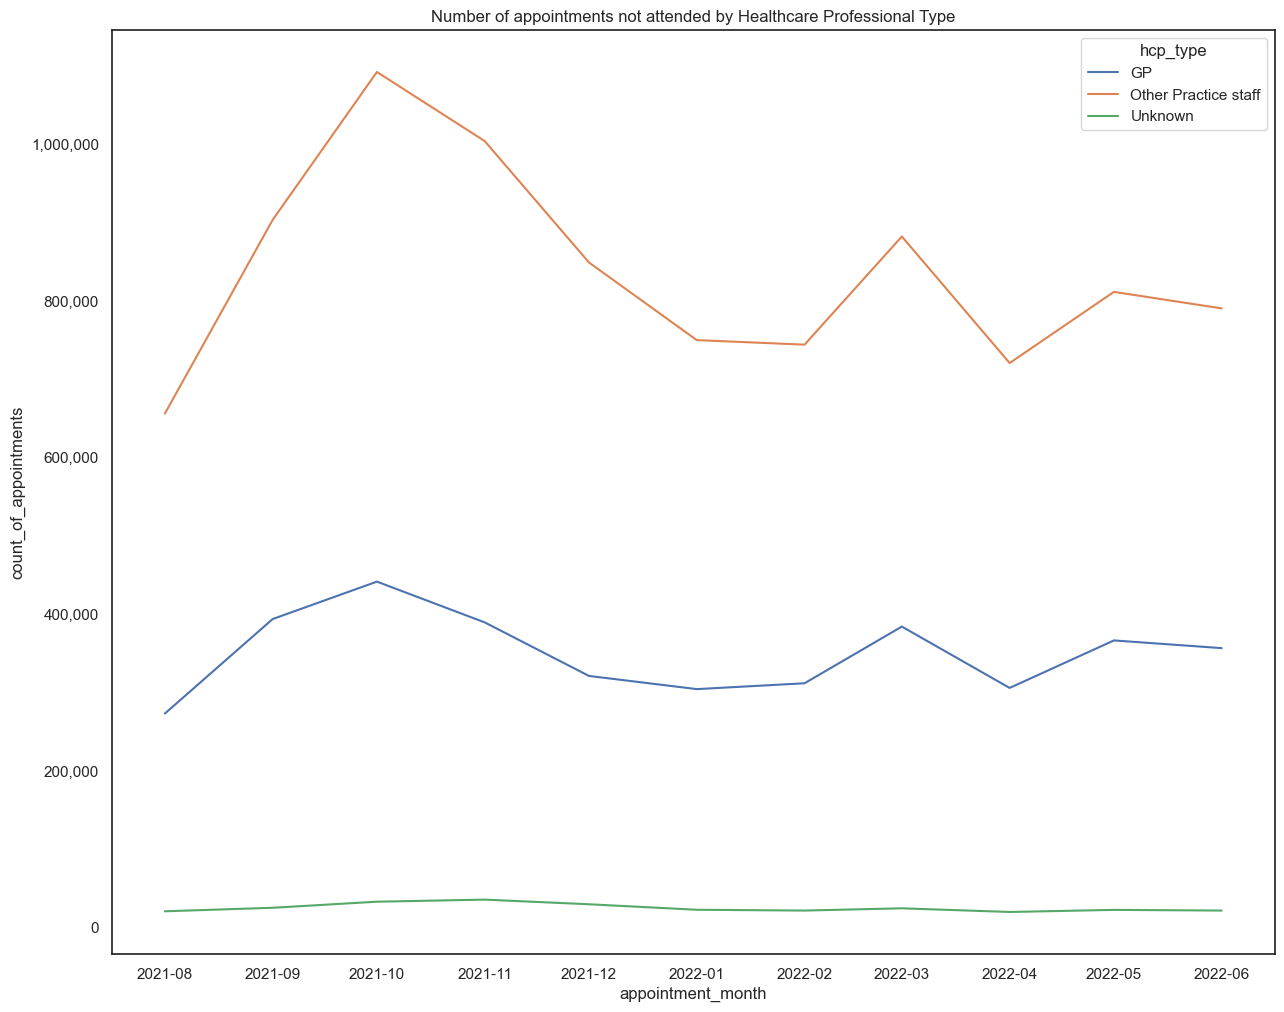

In [54]:
# Group the dataset by month and appointments
ar_DNA_HCP = ar_DNA.groupby(['appointment_month','hcp_type'])[['count_of_appointments']].sum().reset_index()

# Plot the data
sns.lineplot(x='appointment_month', y='count_of_appointments', data=ar_DNA_HCP, hue='hcp_type')
plt.title('Number of appointments not attended by Healthcare Professional Type')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))
plt.savefig("DNA by HCP.png")

#### Observation: Above it seems most of the appointments missed in Oct-21 related to Other Practice Staff. But we cannot tell from the data who these staff were. It would be good to investigate further and find these professions. Lets break this data down further and look at the time between booking and appointments

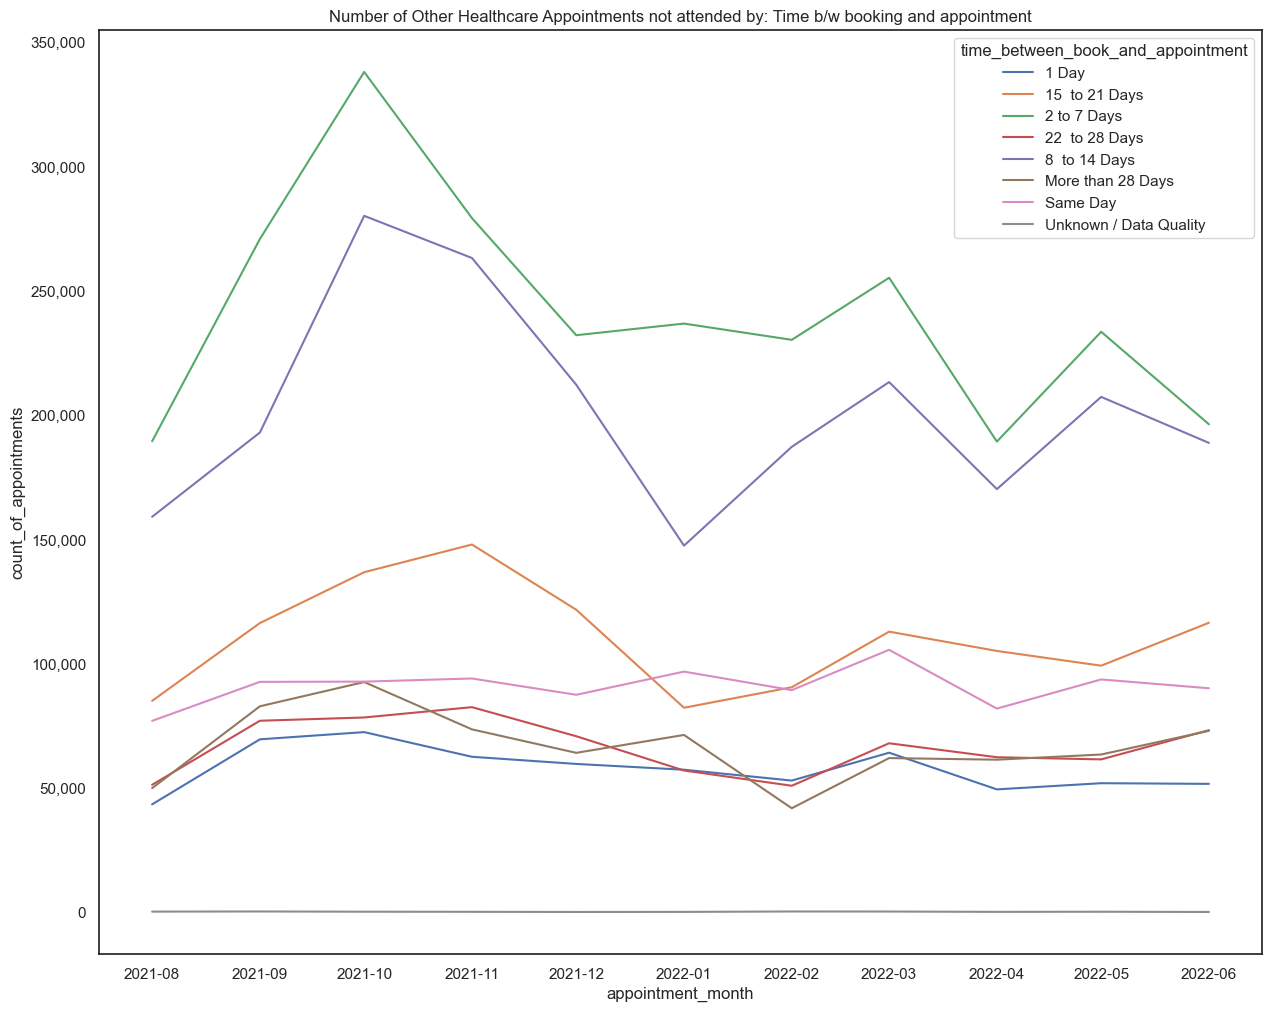

In [55]:
#Filter the dataset to show appointments not attneded
ar_DNA_Other_Staff =ar_DNA[ar_filtered['hcp_type']=='Other Practice staff']

# Group the dataset by month and appointments
ar_DNA_Other_Staff_Grouped = ar_DNA_Other_Staff.groupby(['appointment_month', 'time_between_book_and_appointment'])[['count_of_appointments']].sum().reset_index()

# Plot the data
sns.lineplot(x='appointment_month', y='count_of_appointments', data=ar_DNA_Other_Staff_Grouped, hue='time_between_book_and_appointment')
plt.title('Number of Other Healthcare Appointments not attended by: Time b/w booking and appointment')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))
plt.savefig("DNA by book appnt.png")

#### Observation: Above it seems that most of the appointments missed are for 2-7 days, 8-14 and 15-21 days. There was a spike in Oct-21  but these have gone down gradually.

### Recommendation: Perhaps people miss these appointments due to long wait times. I would recommend the NHS sending letters, text and phone reminders to people when it gets close to the appointment time. This way people will remember to attend appointments

### **Question 4:** Are there changes in terms of appointment type and the busiest months?

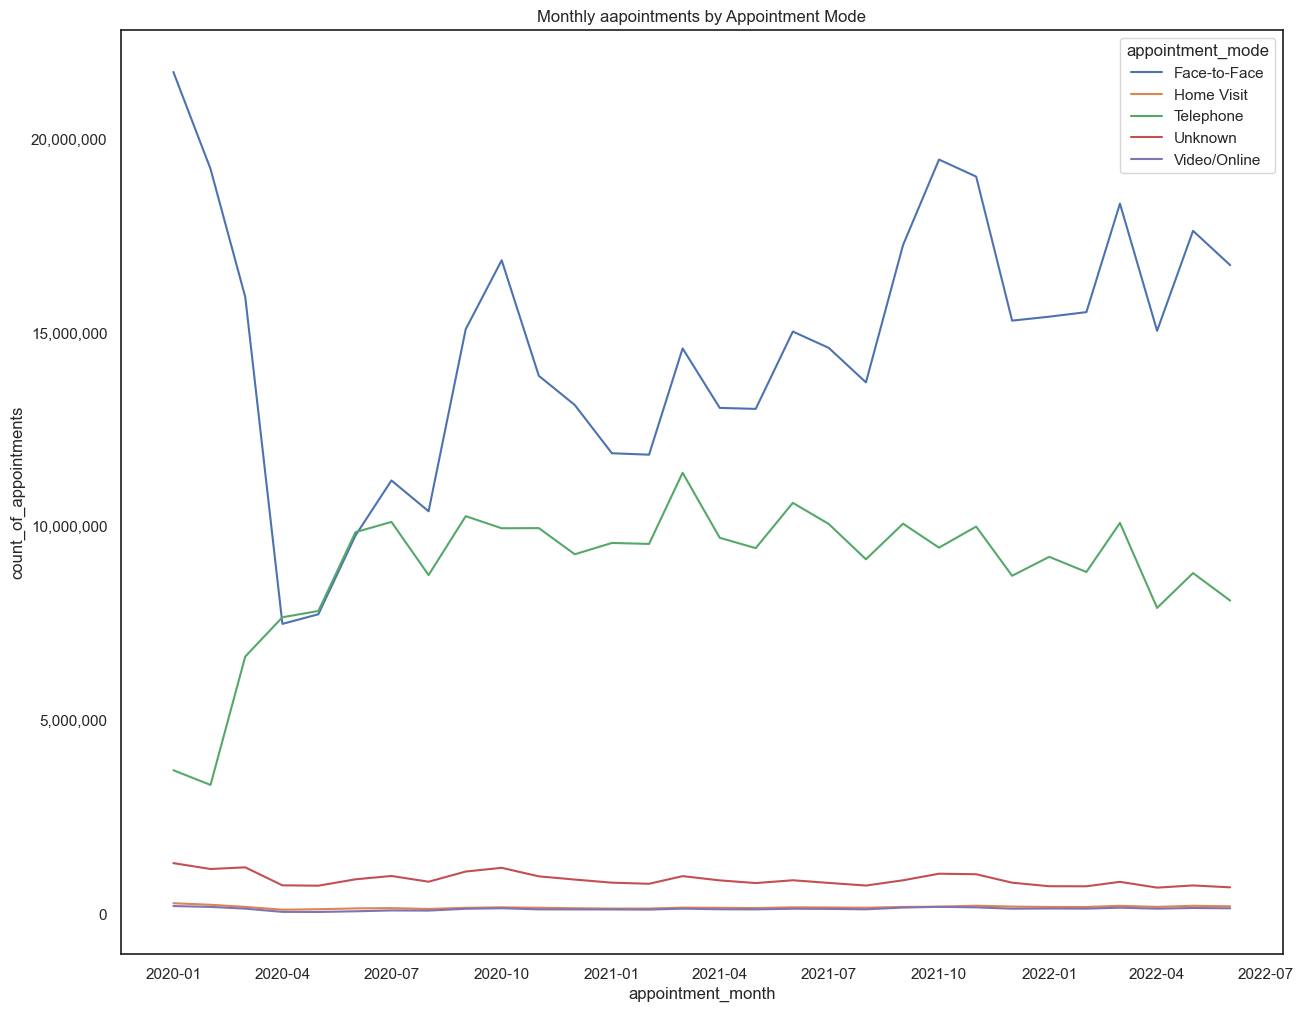

In [56]:
# Group the dataset by month and appointments
ar_appt_mode_grouped = ar.groupby(['appointment_month', 'appointment_mode'])[['count_of_appointments']].sum().reset_index()

# Plot the data
sns.lineplot(x='appointment_month', y='count_of_appointments', data=ar_appt_mode_grouped, hue='appointment_mode')
plt.title('Monthly aapointments by Appointment Mode')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))
plt.savefig("Appointment mode.png")

#### Observations: Above the data shows that at the start of the covid lockdown in March / April 2020 there is steep decline in face to face appointments and telephone appointments have increased considerably. 

#### Sep - Nov-21 appear to be the busiest months, and the number of face to face appointments went up during this time. The other appointment types remained steady. But  since then, both face to face and telephone appointments tend to follow a similar pattern during busy and quiet months.

### Recommendation: Telephone appointments booked via web forms should be encouraged more. Surgeries can call patients and assess whether they need to come in to see a health professional or they should be advised over the phone. 

#### This approach is much quicker. Patients do not need to take time off from work or school to go to a health professional. This should save time on appointments and less appointments will be missed as a result.

### **Question 5 :** How do the various service settings compare?

In [57]:
# Create a new DataFrame consisting of the month of appointment, service settings and the number of appointments.
nc_grouped = nc.groupby(['appointment_month', 'service_setting'])[['count_of_appointments']].sum().reset_index()

In [58]:
# Show summary statistics for each service setting that will be displayed in the boxplot
Boxplot_summary_stats = nc_grouped.groupby('service_setting')['count_of_appointments'].describe(percentiles=[0.25, 0.5, 0.75])[['min', '25%', '50%', '75%', 'max']].reset_index()
Boxplot_summary_stats

,service_setting,min,25%,50%,75%,max
0,Extended Access Provision,160927.0,187140.5,196627.0,209595.5,231905.0
1,General Practice,21575852.0,23157376.0,23680374.0,26564094.5,27767889.0
2,Other,437402.0,456796.5,478813.0,528925.5,558784.0
3,Primary Care Network,432448.0,552230.0,585300.0,657461.5,712280.0
4,Unmapped,758640.0,816008.0,942912.0,1245169.5,1366656.0


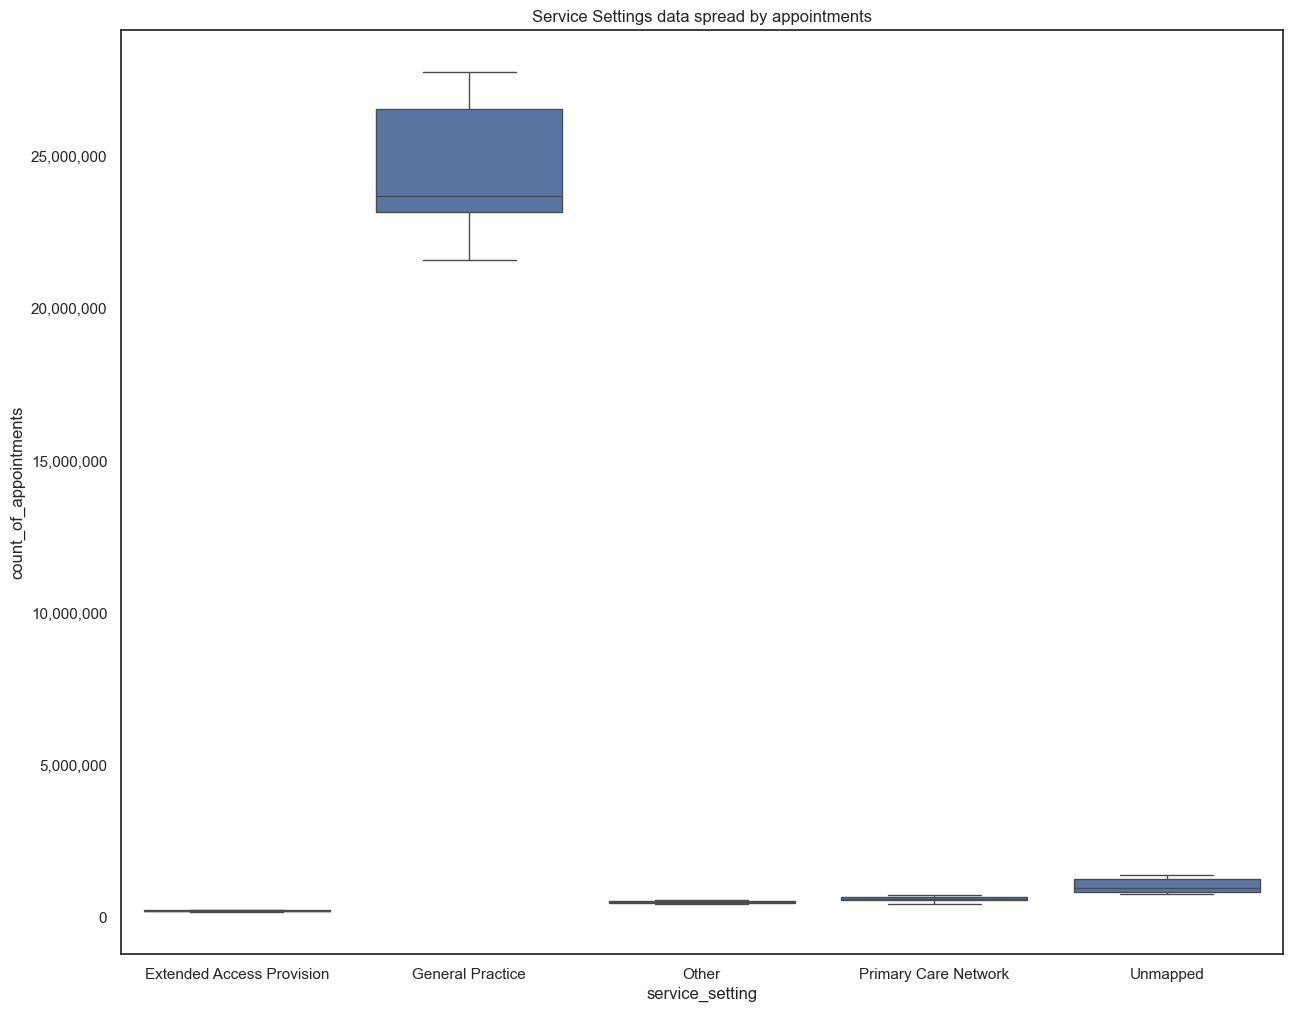

In [59]:
# Plot the data
sns.boxplot(x='service_setting', y='count_of_appointments', data=nc_grouped)
plt.title('Service Settings data spread by appointments')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))
plt.savefig("Boxplot.png")

#### Observations: From the above boxplot it is clar that GP settings account for the most appointments each month with a median of 23,680,374 appointments and a 75th percentile of 26,564,095. The data is right skewed i.e. most of the values lie above the median. These are probably the busier months of Oct and Nov-21 

#### Let us remove GP settings

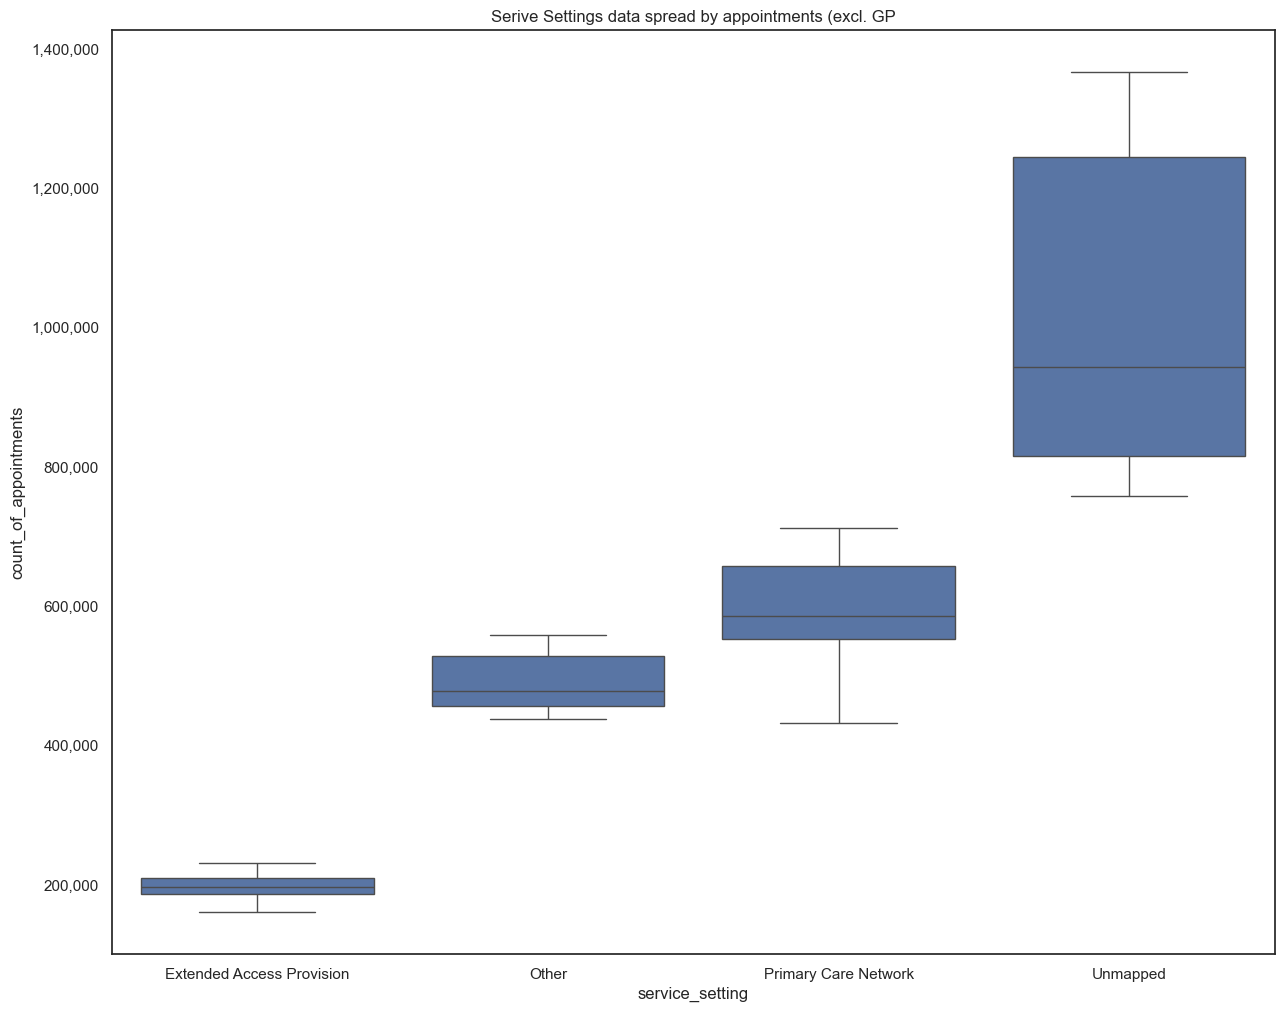

In [60]:
# Exclude GPs from the data
nc_excluding_GP =nc[nc['service_setting']!='General Practice']

nc_excluding_GP_Grouped = nc_excluding_GP.groupby(['appointment_month', 'service_setting'])[['count_of_appointments']].sum().reset_index()

# Plot the data
sns.boxplot(x='service_setting', y='count_of_appointments', data=nc_excluding_GP_Grouped)
plt.title('Serive Settings data spread by appointments (excl. GP')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{abs(x):,.0f}'))
plt.savefig("Boxplot excl GP.png")

#### Observations: The above shows that Extended Access Provision or out of hours have the lowest number of appointments with a median of 196,627 appointments per month. Primary care network has a larger spread and a median value of 585,300 appointments per month. The data is also right skewed with more values above the median. The biggest spread is for the category unmapped with an IQR of 429,162. The median is 942,912 and a 75th percentile of  1,245,170. That is a large number of values unmapped. Work should be done to map these to the correct service settings to gain more insghts on NHS appointments.